File colab này sẽ pull code từ nhánh phụ của github về sau đó sửa một số hàm để thực hiện ablation study

##Phiên bản 'Ourbase':

RGB + Vis Mask + Embedding + Occlusion X5 Loss: Sử dụng 4 kênh đầu vào (ảnh RGB và mặt nạ vùng nhìn thấy), tính năng nhúng danh mục (category embedding), và hàm mất mát Occlusion-Aware Loss với trọng số 5x cho các vùng bị che khuất.

##Các phiên bản 'Ablation Study':

- RGB + Vis Mask (chỉ BCE) + Embedding + Edge Mask: Sử dụng 5 kênh đầu vào (ảnh RGB, mặt nạ vùng nhìn thấy và mặt nạ cạnh), tính năng nhúng danh mục, và hàm mất mát BCE tiêu chuẩn.
- RGB + Visible Mask (chỉ BCE) (Baseline thuần túy): Sử dụng 4 kênh đầu vào (ảnh RGB và mặt nạ vùng nhìn thấy), không sử dụng tính năng nhúng danh mục, và hàm mất mát BCE tiêu chuẩn.
- RGB + Vis Mask + Embedding (chỉ BCE) (Phiên bản Base được đào tạo tiếp): Tương tự phiên bản Baseline thuần túy nhưng có tính năng nhúng danh mục, sử dụng 4 kênh đầu vào và hàm mất mát BCE tiêu chuẩn. Đây là phiên bản tiếp tục quá trình đào tạo.
- RGB + Vis Mask + Edge Mask (chỉ BCE) (Phiên bản Ablation được đào tạo tiếp): Sử dụng 5 kênh đầu vào (ảnh RGB, mặt nạ vùng nhìn thấy và mặt nạ cạnh), tính năng nhúng danh mục và hàm mất mát BCE tiêu chuẩn. Đây là một phiên bản tiếp tục quá trình đào tạo.
Với Spatial Attention: Sử dụng 5 kênh đầu vào (ảnh RGB, mặt nạ vùng nhìn thấy và mặt nạ cạnh), tính năng nhúng danh mục, hàm mất mát Occlusion-Aware Loss, và cơ chế Spatial Attention.
- Đào tạo thêm 30 Epoch cho bản Base (không Attention): Sử dụng 5 kênh đầu vào (ảnh RGB, mặt nạ vùng nhìn thấy và mặt nạ cạnh), tính năng nhúng danh mục, hàm mất mát Occlusion-Aware Loss, và không sử dụng Spatial Attention. Đây là một phiên bản tiếp tục quá trình đào tạo.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. KẾT NỐI DRIVE (Để lát hứng file model)
from google.colab import drive
drive.mount('/content/drive')

# 2. KÉO CODE TỪ GITHUB
%cd /content
!rm -rf amodal_shape_prediction
# Tớ dùng đúng cái link nhánh của cậu đây nhé:
!git clone -b 2.-spartial_attention https://github.com/vothenguyen/amodal_shape_prediction.git

# 3. TẢI DATA BẰNG KAGGLEHUB (Vượt mọi rào cản)
!pip install -q kagglehub
import kagglehub
import os

print("⏳ Đang hút ảnh KITTI từ Kaggle về Colab...")
kitti_path = kagglehub.dataset_download("anupammajhi/kitti-2d-object-detection")

print("⏳ Đang hút nhãn KINS từ Kaggle về Colab...")
kins_path = kagglehub.dataset_download("ryanthenguyen/kins-data")

# Gắn ống nước nối data vào code
!rm -rf /content/kitti_data /content/kins_data
os.symlink(f"{kitti_path}/data_object_image_2", "/content/kitti_data")
os.symlink(kins_path, "/content/kins_data")
print("✅ Nạp đạn Data thành công!")

# 4. THIẾT LẬP ỐNG XẢ VÀO DRIVE
!mkdir -p /content/drive/MyDrive/CV+/checkpoints_kins
!rm -rf /content/amodal_shape_prediction/checkpoints
!ln -s /content/drive/MyDrive/CV+/checkpoints_kins /content/amodal_shape_prediction/checkpoints

# 5. CÀI ĐẶT THƯ VIỆN
%cd /content/amodal_shape_prediction/src
!pip install -q timm albumentations pycocotools tqdm

Mounted at /content/drive
/content
Cloning into 'amodal_shape_prediction'...
remote: Enumerating objects: 273, done.
remote: Counting objects: 100% (273/273), done.
remote: Compressing objects: 100% (183/183), done.
remote: Total 273 (delta 129), reused 209 (delta 83), pack-reused 0 (from 0)
Receiving objects: 100% (273/273), 9.96 MiB | 18.65 MiB/s, done.
Resolving deltas: 100% (129/129), done.
⏳ Đang hút ảnh KITTI từ Kaggle về Colab...
Using Colab cache for faster access to the 'kitti-2d-object-detection' dataset.
⏳ Đang hút nhãn KINS từ Kaggle về Colab...
Using Colab cache for faster access to the 'kins-data' dataset.
✅ Nạp đạn Data thành công!
/content/amodal_shape_prediction/src


**RGB + Vis Mask + EMBEDDING + OCCLUSION X5 LOSS**

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import albumentations as A
import sys

# --- KẾT NỐI DRIVE & IMPORT ---
from google.colab import drive
drive.mount('/content/drive')
sys.path.append('/content/amodal_shape_prediction/src')

from dataset_kins import KINSDataset
from model import AmodalSwinUNet

# ==========================================
# 🌟 HÀM LOSS XỊN XÒ CỦA CẬU: OCCLUSION AWARE LOSS
# ==========================================
class OcclusionAwareLoss(nn.Module):
    def __init__(self, occlusion_weight=5.0):  # THƯỞNG X5 ĐIỂM!!!
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(reduction="none")
        self.occlusion_weight = occlusion_weight

    def forward(self, pred, target, occluded_region):
        bce_loss = self.bce(pred, target)
        weight_matrix = torch.ones_like(target)
        weight_matrix[occluded_region > 0.5] = self.occlusion_weight
        weighted_bce = (bce_loss * weight_matrix).mean()

        pred_prob = torch.sigmoid(pred)
        intersection = (pred_prob * target).sum(dim=(2, 3))
        union = pred_prob.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice_loss = 1.0 - (2.0 * intersection + 1e-6) / (union + 1e-6)

        return weighted_bce + dice_loss.mean()

# ==========================================
# 🔴 CẤU HÌNH: 4 KÊNH + EMBEDDING + OCCLUSION AWARE LOSS 🔴
# ==========================================
SAVE_DIR = "/content/drive/MyDrive/MAPR_Checkpoints/Baseline_Embed_NoEdge_OccLoss"
os.makedirs(SAVE_DIR, exist_ok=True)

def train_embed_no_edge_occloss():
    BATCH_SIZE = 256
    EPOCHS = 30
    LR = 1e-4
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"🚀 CHẾ ĐỘ: 4 Kênh (Không Edge) + Embed + OCCLUSION AWARE LOSS (x5) trên {DEVICE}")

    train_transform = A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), rotate=(-15, 15), p=0.5),
        A.RandomBrightnessContrast(p=0.2),
    ])

    train_dataset = KINSDataset(img_dir="/content/kitti_data/training/image_2",
                               ann_file="/content/kins_data/update_train_2020.json",
                               transform=train_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=12, pin_memory=True, prefetch_factor=2)

    # ---------------------------------------------------------
    # KHỞI TẠO MODEL VỚI CẤU HÌNH ĐỐI CHỨNG (4 KÊNH)
    # ---------------------------------------------------------
    model = AmodalSwinUNet(
        num_classes=20,
        use_spatial_attention=False,
        in_chans=4,                  # QUAY VỀ 4 KÊNH (CẮT EDGE MASK)
        use_category_embedding=True  # VẪN GIỮ EMBEDDING
    ).to(DEVICE)

    # KHAI BÁO HÀM LOSS "VŨ KHÍ BÍ MẬT"
    criterion = OcclusionAwareLoss(occlusion_weight=5.0)
    optimizer = optim.AdamW(model.parameters(), lr=LR)
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

        for inputs, targets, _, class_ids in pbar:
            # ---> 1. Trích xuất Visible Mask để tính toán vùng khuất <---
            visible_masks = inputs[:, 3:4, :, :].to(DEVICE, non_blocking=True)

            # ---> 2. Cắt lấy 4 kênh nạp vào Model (Bỏ kênh thứ 5 - Edge Mask) <---
            inputs = inputs[:, :4, :, :].to(DEVICE, non_blocking=True)

            targets = targets.unsqueeze(1).float().to(DEVICE, non_blocking=True)
            class_ids = class_ids.to(DEVICE, non_blocking=True)

            # ---> 3. Tính toán ma trận Occluded Region mớm cho Loss <---
            occluded_region = (targets - visible_masks).clamp(0, 1)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(inputs, class_ids)

                # Gọi hàm Loss x5 điểm thưởng
                loss = criterion(outputs, targets, occluded_region)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(train_loader)
        print(f"✅ Kết thúc Epoch {epoch+1} | Trung bình Loss: {avg_loss:.4f}")

        torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"embed_no_edge_occloss_epoch_{epoch+1}.pth"))

if __name__ == "__main__":
    train_embed_no_edge_occloss()

KeyboardInterrupt: 

In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader
import os
import sys
import albumentations as A

# --- KẾT NỐI DRIVE & CHỈ ĐỊNH ĐƯỜNG DẪN CODE ---
from google.colab import drive
drive.mount('/content/drive')
sys.path.append('/content/amodal_shape_prediction/src')

from dataset_kins import KINSDataset
from model import AmodalSwinUNet

# --- CẤU HÌNH ĐÁNH GIÁ ĐÚNG BẢN OCCLUSION AWARE LOSS ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Trỏ đúng vào tạ của bản 4 Kênh + Embedding + Occlusion Loss
MODEL_WEIGHTS = "/content/drive/MyDrive/MAPR_Checkpoints/Baseline_Embed_NoEdge_OccLoss/embed_no_edge_occloss_epoch_24.pth"

# ==========================================
# HÀM TÍNH TOÁN METRIC CHUẨN SOTA (Giữ nguyên bản xịn của cậu)
# ==========================================
def calculate_instance_metrics(pred, target, visible):
    """Tính điểm chuẩn SOTA cho từng chiếc xe một"""
    pred = (pred > 0.5).float()
    gt_occ = (target - visible) > 0.5
    pred_occ = (pred - visible) > 0.5

    batch_size = pred.shape[0]
    batch_overall_iou = []
    batch_occ_iou = []
    batch_occ_recall = []

    for i in range(batch_size):
        # 1. Overall mIoU
        inter_o = (pred[i] * target[i]).sum()
        union_o = pred[i].sum() + target[i].sum() - inter_o
        batch_overall_iou.append((inter_o / union_o).item() if union_o > 0 else 1.0)

        # 2. Occlusion (Chỉ tính vùng khuất)
        p_occ = pred_occ[i]
        t_occ = gt_occ[i]
        inter_occ = (p_occ * t_occ).sum()
        union_occ = p_occ.sum() + t_occ.sum() - inter_occ
        gt_occ_sum = t_occ.sum()

        if gt_occ_sum.item() > 0:
            batch_occ_iou.append((inter_occ / union_occ).item() if union_occ > 0 else 0.0)
            batch_occ_recall.append((inter_occ / gt_occ_sum).item())

    return batch_overall_iou, batch_occ_iou, batch_occ_recall

# ==========================================
# HÀM ĐÁNH GIÁ CHÍNH
# ==========================================
def evaluate_embed_no_edge_occloss():
    print(f"🚀 BẮT ĐẦU ĐÁNH GIÁ BẢN (4 KÊNH + EMBED + OCC LOSS) TRÊN {DEVICE}")

    # 1. Khởi tạo Dataset với lưới an toàn 224x224
    transform_val = A.Compose([A.Resize(224, 224)], is_check_shapes=False)
    val_dataset = KINSDataset(
        img_dir="/content/kitti_data/testing/image_2",
        ann_file="/content/kins_data/update_test_2020.json",
        transform=transform_val
    )

    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=12, pin_memory=True, prefetch_factor=2)

    # 2. Khởi tạo Model KHỚP TUYỆT ĐỐI VỚI BẢN TRAIN (4 Kênh, Bật Embed)
    model = AmodalSwinUNet(
        num_classes=20,
        use_spatial_attention=False, # Đang tắt
        in_chans=4,                  # CHỈ 4 KÊNH (Bỏ Edge)
        use_category_embedding=True  # BẬT EMBEDDING
    ).to(DEVICE)

    # 3. Load tạ (Weights)
    print(f"📦 Đang load tạ từ: {MODEL_WEIGHTS}")
    if not os.path.exists(MODEL_WEIGHTS):
        print("❌ Chưa tìm thấy file tạ! Lại phải ôm cây đợi thỏ rồi, đợi model train xong đã nhé.")
        return

    model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=DEVICE))
    model.eval()

    all_overall_ious = []
    all_occ_ious = []
    all_occ_recalls = []

    print("Đang quét dữ liệu chấm điểm...")
    with torch.no_grad():
        for inputs, targets, _, class_ids in tqdm(val_loader):

            # ÉP XUỐNG CÒN 4 KÊNH ĐẦU VÀO
            inputs = inputs[:, :4, :, :].to(DEVICE, non_blocking=True)
            # Tách Visible Mask để tính điểm (lấy từ kênh 3)
            visible_masks = inputs[:, 3:4, :, :]



            targets = targets.unsqueeze(1).to(DEVICE, non_blocking=True)
            class_ids = class_ids.to(DEVICE, non_blocking=True)

            # Quét qua model với class_ids
            outputs = model(inputs, class_ids)
            pred_probs = torch.sigmoid(outputs)

            # Tính Metric
            b_overall, b_occ, b_recall = calculate_instance_metrics(pred_probs, targets, visible_masks)

            all_overall_ious.extend(b_overall)
            all_occ_ious.extend(b_occ)
            all_occ_recalls.extend(b_recall)

    # 4. Tổng hợp & In Bảng Vàng
    final_overall_miou = np.mean(all_overall_ious) * 100
    final_occ_miou = np.mean(all_occ_ious) * 100 if len(all_occ_ious) > 0 else 0
    final_occ_recall = np.mean(all_occ_recalls) * 100 if len(all_occ_recalls) > 0 else 0

    print("\n" + "="*50)
    print("🏆 KẾT QUẢ: 4 KÊNH + EMBEDDING + OCCLUSION AWARE LOSS 🏆")
    print(f" 🎯 Overall mIoU   : {final_overall_miou:.2f}%")
    print(f" 👻 Occlusion mIoU : {final_occ_miou:.2f}%")
    print(f" 🔍 Occ Recall     : {final_occ_recall:.2f}%")
    print("="*50)

    if final_occ_miou > 48.0:
        print("\n🌟 CHÚC MỪNG: Hàm Loss x5 của cậu đã chứng minh được sự vượt trội!")

if __name__ == "__main__":
    evaluate_embed_no_edge_occloss()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 BẮT ĐẦU ĐÁNH GIÁ BẢN (4 KÊNH + EMBED + OCC LOSS) TRÊN cuda
loading annotations into memory...
Done (t=4.72s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 92625 vật thể!
📦 Đang load tạ từ: /content/drive/MyDrive/MAPR_Checkpoints/Baseline_Embed_NoEdge_OccLoss/embed_no_edge_occloss_epoch_24.pth
Đang quét dữ liệu chấm điểm...


100%|██████████| 724/724 [04:51<00:00,  2.48it/s]



🏆 KẾT QUẢ: 4 KÊNH + EMBEDDING + OCCLUSION AWARE LOSS 🏆
 🎯 Overall mIoU   : 85.94%
 👻 Occlusion mIoU : 51.86%
 🔍 Occ Recall     : 62.74%

🌟 CHÚC MỪNG: Hàm Loss x5 của cậu đã chứng minh được sự vượt trội!


**RGB + Vis Mask (BCE only) + EMBEDDING + EDGE MASK**

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import albumentations as A
import sys

# --- KẾT NỐI DRIVE & IMPORT ---
from google.colab import drive
drive.mount('/content/drive')
sys.path.append('/content/amodal_shape_prediction/src')

from dataset_kins import KINSDataset
from model import AmodalSwinUNet

# 🔴 CẤU HÌNH BẢN MỚI: 5 KÊNH + EMBEDDING + BCE ONLY 🔴
SAVE_DIR = "/content/drive/MyDrive/MAPR_Checkpoints/Baseline_Embed_Edge"
os.makedirs(SAVE_DIR, exist_ok=True)

def train_embed_edge_baseline():
    BATCH_SIZE = 128
    EPOCHS = 30
    LR = 1e-4
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"🚀 CHẾ ĐỘ: 5 Kênh (RGB+Vis+Edge) + Categorical Embedding + BCE Only trên {DEVICE}")

    train_transform = A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), rotate=(-15, 15), p=0.5),
        A.RandomBrightnessContrast(p=0.2),
    ])

    train_dataset = KINSDataset(img_dir="/content/kitti_data/training/image_2",
                               ann_file="/content/kins_data/update_train_2020.json",
                               transform=train_transform)

    # DataLoader ép xung cho A100
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=12, pin_memory=True, prefetch_factor=2)

    # ---------------------------------------------------------
    # KHỞI TẠO MODEL VỚI CẤU HÌNH MỚI
    # ---------------------------------------------------------
    model = AmodalSwinUNet(
        num_classes=20,
        use_spatial_attention=False, # Tắt mắt thần
        in_chans=5,                  # BẬT 5 KÊNH (Đã có Edge Mask)
        use_category_embedding=True  # BẬT EMBEDDING!
    ).to(DEVICE)

    # Loss BCE thuần túy
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR)
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

        for inputs, targets, occluded, class_ids in pbar:
            # 1. Lấy toàn bộ 5 kênh (Không cắt [:4] như bản Pure Baseline nữa)
            inputs = inputs.to(DEVICE, non_blocking=True)
            targets = targets.unsqueeze(1).float().to(DEVICE, non_blocking=True)

            # 2. Truyền class_ids thật vào (Vì giờ đã bật Embedding)
            class_ids = class_ids.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                # Model sẽ nhai cả 5 kênh và dùng class_ids để giải mã nhãn
                outputs = model(inputs, class_ids)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(train_loader)
        print(f"✅ Kết thúc Epoch {epoch+1} | Trung bình Loss: {avg_loss:.4f}")

        # Lưu tạ
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"embed_edge_epoch_{epoch+1}.pth"))

if __name__ == "__main__":
    train_embed_edge_baseline()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 CHẾ ĐỘ: 5 Kênh (RGB+Vis+Edge) + Categorical Embedding + BCE Only trên cuda
loading annotations into memory...
Done (t=6.19s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 95460 vật thể!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

/tmp/ipykernel_767/2536389531.py:58: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1/30:   0%|          | 0/746 [00:00<?, ?it/s]/tmp/ipykernel_767/2536389531.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/30: 100%|██████████| 746/746 [05:05<00:00,  2.44it/s, loss=0.15]


✅ Kết thúc Epoch 1 | Trung bình Loss: 0.2800


...

✅ Kết thúc Epoch 28 | Trung bình Loss: 0.0008


Epoch 29/30: 100%|██████████| 746/746 [04:57<00:00,  2.50it/s, loss=0.00069]


✅ Kết thúc Epoch 29 | Trung bình Loss: 0.0009


Epoch 30/30: 100%|██████████| 746/746 [04:58<00:00,  2.50it/s, loss=0.00127]


✅ Kết thúc Epoch 30 | Trung bình Loss: 0.0008


In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader
import os
import sys
import albumentations as A

# --- CHỈ ĐỊNH ĐƯỜNG DẪN ĐỂ IMPORT CODE CỦA CẬU ---
sys.path.append('/content/amodal_shape_prediction/src')
from dataset_kins import KINSDataset
from model import AmodalSwinUNet

# --- CẤU HÌNH ĐÁNH GIÁ ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Trỏ đúng vào thư mục và file tạ của bản có Embedding + Edge Mask
MODEL_WEIGHTS = "/content/drive/MyDrive/MAPR_Checkpoints/Baseline_Embed_Edge/embed_edge_epoch_30.pth"

# ==========================================
# HÀM TÍNH TOÁN METRIC CHUẨN SOTA
# ==========================================
def calculate_instance_metrics(pred, target, visible):
    """Tính điểm chuẩn SOTA cho từng chiếc xe một"""
    pred = (pred > 0.5).float()
    gt_occ = (target - visible) > 0.5
    pred_occ = (pred - visible) > 0.5

    batch_size = pred.shape[0]
    batch_overall_iou = []
    batch_occ_iou = []
    batch_occ_recall = []

    for i in range(batch_size):
        # 1. Overall mIoU
        inter_o = (pred[i] * target[i]).sum()
        union_o = pred[i].sum() + target[i].sum() - inter_o
        batch_overall_iou.append((inter_o / union_o).item() if union_o > 0 else 1.0)

        # 2. Occlusion (Chỉ tính vùng khuất)
        p_occ = pred_occ[i]
        t_occ = gt_occ[i]
        inter_occ = (p_occ * t_occ).sum()
        union_occ = p_occ.sum() + t_occ.sum() - inter_occ
        gt_occ_sum = t_occ.sum()

        # Dùng .item() để chống lỗi của PyTorch
        if gt_occ_sum.item() > 0:
            batch_occ_iou.append((inter_occ / union_occ).item() if union_occ > 0 else 0.0)
            batch_occ_recall.append((inter_occ / gt_occ_sum).item())

    return batch_overall_iou, batch_occ_iou, batch_occ_recall

# ==========================================
# HÀM ĐÁNH GIÁ BẢN EMBEDDING + EDGE MASK
# ==========================================
def evaluate_embed_edge_baseline():
    print(f"🚀 BẮT ĐẦU ĐÁNH GIÁ BẢN EMBED + EDGE TRÊN {DEVICE}")

    # 1. Khởi tạo Dataset & DataLoader (Nhớ Ép kích thước về 224)
    transform_val = A.Compose([A.Resize(224, 224)], is_check_shapes=False)
    val_dataset = KINSDataset(
        img_dir="/content/kitti_data/testing/image_2",
        ann_file="/content/kins_data/update_test_2020.json",
        transform=transform_val
    )

    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=12, pin_memory=True, prefetch_factor=2)

    # 2. Khởi tạo Model ĐÚNG CẤU HÌNH ĐÃ TRAIN
    model = AmodalSwinUNet(
        num_classes=20,
        use_spatial_attention=False, # Vẫn tắt mắt thần
        in_chans=5,                  # 5 KÊNH (Đã có Edge Mask)
        use_category_embedding=True  # BẬT EMBEDDING
    ).to(DEVICE)

    # 3. Load tạ (Weights)
    print(f"📦 Đang load tạ từ: {MODEL_WEIGHTS}")
    if not os.path.exists(MODEL_WEIGHTS):
        print("❌ Chưa tìm thấy file tạ! Kiểm tra xem model đã train xong chưa nhé.")
        return

    model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=DEVICE))
    model.eval()

    all_overall_ious = []
    all_occ_ious = []
    all_occ_recalls = []

    print("Đang quét dữ liệu chấm điểm...")
    with torch.no_grad():
        for inputs, targets, occluded, class_ids in tqdm(val_loader):
            # Lấy toàn bộ 5 kênh đầu vào, không cắt xén nữa
            inputs = inputs.to(DEVICE, non_blocking=True)
            targets = targets.unsqueeze(1).to(DEVICE, non_blocking=True)
            class_ids = class_ids.to(DEVICE, non_blocking=True) # Đưa class_ids lên GPU

            # Tách Visible Mask từ input (Kênh số 3, index 3) để tính điểm vùng khuất
            visible_masks = inputs[:, 3:4, :, :]

            # Quét qua model (Lần này class_ids sẽ thực sự phát huy tác dụng)
            outputs = model(inputs, class_ids)
            pred_probs = torch.sigmoid(outputs)

            # Tính toán Metric
            b_overall, b_occ, b_recall = calculate_instance_metrics(pred_probs, targets, visible_masks)

            all_overall_ious.extend(b_overall)
            all_occ_ious.extend(b_occ)
            all_occ_recalls.extend(b_recall)

    # 4. Tổng hợp kết quả
    final_overall_miou = np.mean(all_overall_ious) * 100
    final_occ_miou = np.mean(all_occ_ious) * 100 if len(all_occ_ious) > 0 else 0
    final_occ_recall = np.mean(all_occ_recalls) * 100 if len(all_occ_recalls) > 0 else 0

    print("\n" + "="*50)
    print("🏆 KẾT QUẢ ĐÁNH GIÁ (5 KÊNH + EMBEDDING - BCE ONLY) 🏆")
    print(f" 🎯 Overall mIoU   : {final_overall_miou:.2f}%")
    print(f" 👻 Occlusion mIoU : {final_occ_miou:.2f}%")
    print(f" 🔍 Occ Recall     : {final_occ_recall:.2f}%")
    print("="*50)

if __name__ == "__main__":
    evaluate_embed_edge_baseline()

🚀 BẮT ĐẦU ĐÁNH GIÁ BẢN EMBED + EDGE TRÊN cuda
loading annotations into memory...
Done (t=5.40s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 92625 vật thể!
📦 Đang load tạ từ: /content/drive/MyDrive/MAPR_Checkpoints/Baseline_Embed_Edge/embed_edge_epoch_30.pth
Đang quét dữ liệu chấm điểm...


100%|██████████| 724/724 [04:43<00:00,  2.56it/s]



🏆 KẾT QUẢ ĐÁNH GIÁ (5 KÊNH + EMBEDDING - BCE ONLY) 🏆
 🎯 Overall mIoU   : 85.80%
 👻 Occlusion mIoU : 47.99%
 🔍 Occ Recall     : 53.22%


**RGB + VISIBLE MASK (BCE ONLY)**

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import albumentations as A
import sys

# --- KẾT NỐI DRIVE & IMPORT ---
from google.colab import drive
drive.mount('/content/drive')
sys.path.append('/content/amodal_shape_prediction/src')

from dataset_kins import KINSDataset
from model import AmodalSwinUNet

# 🔴 CẤU HÌNH BẢN PURE BASELINE (KHÔNG EMBEDDING, 4 KÊNH, BCE) 🔴
SAVE_DIR = "/content/drive/MyDrive/MAPR_Checkpoints/Pure_Baseline_NoEmb"
os.makedirs(SAVE_DIR, exist_ok=True)

def train_pure_baseline():
    BATCH_SIZE = 128
    EPOCHS = 30
    LR = 1e-4
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"🚀 CHẾ ĐỘ: PURE BASELINE (No Category Embedding, 4 Channels) trên {DEVICE}")

    train_transform = A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), rotate=(-15, 15), p=0.5),
        A.RandomBrightnessContrast(p=0.2),
    ])

    train_dataset = KINSDataset(img_dir="/content/kitti_data/training/image_2",
                               ann_file="/content/kins_data/update_train_2020.json",
                               transform=train_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=12, pin_memory=True, prefetch_factor=2)

    # KHỞI TẠO MODEL VỚI CÁC CÔNG TẮC ĐƯỢC TẮT SẠCH
    model = AmodalSwinUNet(
        num_classes=20,
        use_spatial_attention=False,
        in_chans=4,
        use_category_embedding=False # TẮT EMBEDDING!
    ).to(DEVICE)

    # Loss thuần túy
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR)
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

        for inputs, targets, occluded, class_ids in pbar:
            inputs = inputs[:, :4, :, :].to(DEVICE, non_blocking=True) # Chỉ lấy 4 kênh
            targets = targets.unsqueeze(1).float().to(DEVICE, non_blocking=True)
            class_ids = class_ids.to(DEVICE, non_blocking=True) # Dù pass vào nhưng model sẽ bỏ qua

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(inputs, class_ids)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(train_loader)
        print(f"✅ Kết thúc Epoch {epoch+1} | Trung bình Loss: {avg_loss:.4f}")

        torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"pure_base_epoch_{epoch+1}.pth"))

if __name__ == "__main__":
    train_pure_baseline()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 CHẾ ĐỘ: PURE BASELINE (No Category Embedding, 4 Channels) trên cuda
loading annotations into memory...
Done (t=4.63s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 95460 vật thể!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

/tmp/ipykernel_712/943942674.py:55: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1/30:   0%|          | 0/746 [00:00<?, ?it/s]/tmp/ipykernel_712/943942674.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/30: 100%|██████████| 746/746 [04:42<00:00,  2.64it/s, loss=0.1]


✅ Kết thúc Epoch 1 | Trung bình Loss: 0.2106


...

✅ Kết thúc Epoch 28 | Trung bình Loss: 0.0009


Epoch 29/30: 100%|██████████| 746/746 [04:39<00:00,  2.67it/s, loss=0.000766]


✅ Kết thúc Epoch 29 | Trung bình Loss: 0.0009


Epoch 30/30: 100%|██████████| 746/746 [04:38<00:00,  2.68it/s, loss=0.000498]


✅ Kết thúc Epoch 30 | Trung bình Loss: 0.0009


In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader
import os
import sys
import albumentations as A

# --- CHỈ ĐỊNH ĐƯỜNG DẪN ĐỂ IMPORT CODE CỦA CẬU ---
sys.path.append('/content/amodal_shape_prediction/src')
from dataset_kins import KINSDataset
from model import AmodalSwinUNet

# --- CẤU HÌNH ĐÁNH GIÁ ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Trỏ đúng vào thư mục và file tạ (epoch 30) mà cậu cấu hình lúc nãy
MODEL_WEIGHTS = "/content/drive/MyDrive/MAPR_Checkpoints/Pure_Baseline_NoEmb/pure_base_epoch_30.pth"

# ==========================================
# HÀM TÍNH TOÁN METRIC CHUẨN SOTA
# (Lấy từ code xịn của cậu ghép sang)
# ==========================================
def calculate_instance_metrics(pred, target, visible):
    """Tính điểm chuẩn SOTA cho từng chiếc xe một"""
    pred = (pred > 0.5).float()
    gt_occ = (target - visible) > 0.5
    pred_occ = (pred - visible) > 0.5

    batch_size = pred.shape[0]
    batch_overall_iou = []
    batch_occ_iou = []
    batch_occ_recall = []

    for i in range(batch_size):
        # 1. Overall mIoU
        inter_o = (pred[i] * target[i]).sum()
        union_o = pred[i].sum() + target[i].sum() - inter_o
        batch_overall_iou.append((inter_o / union_o).item() if union_o > 0 else 1.0)

        # 2. Occlusion (Chỉ tính vùng khuất)
        p_occ = pred_occ[i]
        t_occ = gt_occ[i]
        inter_occ = (p_occ * t_occ).sum()
        union_occ = p_occ.sum() + t_occ.sum() - inter_occ
        gt_occ_sum = t_occ.sum()

        # Dùng .item() để chống lỗi "ambiguous boolean" của PyTorch
        if gt_occ_sum.item() > 0:
            batch_occ_iou.append((inter_occ / union_occ).item() if union_occ > 0 else 0.0)
            batch_occ_recall.append((inter_occ / gt_occ_sum).item())

    return batch_overall_iou, batch_occ_iou, batch_occ_recall

# ==========================================
# HÀM ĐÁNH GIÁ PURE BASELINE
# ==========================================
def evaluate_pure_baseline():
    print(f"🚀 BẮT ĐẦU ĐÁNH GIÁ PURE BASELINE TRÊN {DEVICE}")

    # 1. Khởi tạo Dataset & DataLoader
    transform_val = A.Compose([A.Resize(224, 224)], is_check_shapes=False)
    val_dataset = KINSDataset(
        img_dir="/content/kitti_data/testing/image_2",
        ann_file="/content/kins_data/update_test_2020.json",
        transform=transform_val
    )

    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=12, pin_memory=True, prefetch_factor=2)

    # 2. Khởi tạo Model CHUẨN PURE BASELINE
    model = AmodalSwinUNet(
        num_classes=20,
        use_spatial_attention=False, # Tắt mắt thần
        in_chans=4,                  # Chỉ 4 kênh
        use_category_embedding=False # TẮT EMBEDDING
    ).to(DEVICE)

    # 3. Load tạ (Weights)
    print(f"📦 Đang load tạ từ: {MODEL_WEIGHTS}")
    if not os.path.exists(MODEL_WEIGHTS):
        print("❌ Chưa tìm thấy file tạ! Kiểm tra lại đường dẫn.")
        return

    model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=DEVICE))
    model.eval()

    all_overall_ious = []
    all_occ_ious = []
    all_occ_recalls = []

    print("Đang quét dữ liệu chấm điểm...")
    with torch.no_grad():
        for inputs, targets, occluded, class_ids in tqdm(val_loader):
            # Cắt lấy đúng 4 kênh
            inputs = inputs[:, :4, :, :].to(DEVICE, non_blocking=True)

            # Quan trọng: Thêm .unsqueeze(1) cho targets giống code xịn của cậu
            targets = targets.unsqueeze(1).to(DEVICE, non_blocking=True)

            # Tách Visible Mask
            visible_masks = inputs[:, 3:4, :, :]

            # Quét qua model
            outputs = model(inputs, class_ids.to(DEVICE))
            pred_probs = torch.sigmoid(outputs)

            # Tính toán Metric
            b_overall, b_occ, b_recall = calculate_instance_metrics(pred_probs, targets, visible_masks)

            all_overall_ious.extend(b_overall)
            all_occ_ious.extend(b_occ)
            all_occ_recalls.extend(b_recall)

    # 4. Tổng hợp kết quả
    final_overall_miou = np.mean(all_overall_ious) * 100
    final_occ_miou = np.mean(all_occ_ious) * 100 if len(all_occ_ious) > 0 else 0
    final_occ_recall = np.mean(all_occ_recalls) * 100 if len(all_occ_recalls) > 0 else 0

    print("\n" + "="*50)
    print("🏆 KẾT QUẢ ĐÁNH GIÁ PURE BASELINE (4 KÊNH - NO EMBED) 🏆")
    print(f" 🎯 Overall mIoU   : {final_overall_miou:.2f}%")
    print(f" 👻 Occlusion mIoU : {final_occ_miou:.2f}%")
    print(f" 🔍 Occ Recall     : {final_occ_recall:.2f}%")
    print("="*50)

if __name__ == "__main__":
    evaluate_pure_baseline()

🚀 BẮT ĐẦU ĐÁNH GIÁ PURE BASELINE TRÊN cuda
loading annotations into memory...
Done (t=4.80s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 92625 vật thể!
📦 Đang load tạ từ: /content/drive/MyDrive/MAPR_Checkpoints/Pure_Baseline_NoEmb/pure_base_epoch_30.pth
Đang quét dữ liệu chấm điểm...


100%|██████████| 724/724 [04:21<00:00,  2.77it/s]



🏆 KẾT QUẢ ĐÁNH GIÁ PURE BASELINE (4 KÊNH - NO EMBED) 🏆
 🎯 Overall mIoU   : 85.23%
 👻 Occlusion mIoU : 50.47%
 🔍 Occ Recall     : 60.37%


**1. RGB + Vis Mask + embedding (BCE only)**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import albumentations as A
from torch.utils.data import DataLoader
import numpy as np
import sys
import os

# --- KẾT NỐI GOOGLE DRIVE ---
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/MAPR_Checkpoints/Baseline_4Chan'

# Nhập các module tự viết
sys.path.append('/content/amodal_shape_prediction/src')
from dataset_kins import KINSDataset
from model import AmodalSwinUNet

# ==========================================
# CẤU HÌNH RESUME TRAINING (TỪ EPOCH 7 -> 30)
# ==========================================
EPOCHS = 30
START_EPOCH = 6         # Epoch đã chạy xong (Bắt đầu chạy từ index 6, tức là Epoch 7)
BATCH_SIZE = 128      # Đã lên A100 (40GB VRAM) thì mạnh dạn nâng Batch Size lên 32 cho phóng lẹ!
LR = 1e-4

def calculate_metrics(pred, target, visible):
    pred = (pred > 0.5).float()
    intersection_overall = (pred * target).sum()
    union_overall = pred.sum() + target.sum() - intersection_overall
    overall_iou = (intersection_overall / union_overall).item() if union_overall > 0 else 1.0

    gt_occ = (target - visible) > 0.5
    pred_occ = (pred - visible) > 0.5
    intersection_occ = (pred_occ.float() * gt_occ.float()).sum()
    union_occ = pred_occ.float().sum() + gt_occ.float().sum() - intersection_occ

    if gt_occ.float().sum() > 0:
        occ_iou = (intersection_occ / union_occ).item() if union_occ > 0 else 0.0
    else:
        occ_iou = -1.0
    return overall_iou, occ_iou

def resume_training():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 BẮT ĐẦU CHẠY TIẾP TRÊN {DEVICE} (GPU A100 SIÊU TỐC)")

    # 1. Chuẩn bị Dữ liệu
    ann_file = "/content/kins_data/update_train_2020.json"
    img_dir = "/content/kitti_data/training/image_2"
    transform = A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.ColorJitter(p=0.3)
    ], is_check_shapes=False)

    dataset = KINSDataset(img_dir=img_dir, ann_file=ann_file, transform=transform)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=12, pin_memory=True, prefetch_factor=2)

    # 2. Khởi tạo Model (4 Kênh)
    model = AmodalSwinUNet(num_classes=20, use_spatial_attention=False, in_chans=4).to(DEVICE)

    # 3. LOAD LẠI TẠ TỪ EPOCH 6
    checkpoint_path = os.path.join(SAVE_DIR, "baseline_epoch_6.pth")
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    print(f"✅ Đã load thành công tạ từ: {checkpoint_path}")

    # 4. Optimizer & Loss
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion_bce = nn.BCEWithLogitsLoss()

    # 5. Vòng lặp Training (Chạy tiếp từ START_EPOCH)
    model.train()
    for epoch in range(START_EPOCH, EPOCHS):
        total_loss = 0
        total_overall_iou = 0
        total_occ_iou = 0
        valid_occ_batches = 0

        for batch_idx, (inputs, targets, occluded, class_ids) in enumerate(dataloader):
            inputs = inputs[:, :4, :, :].to(DEVICE)
            targets = targets.unsqueeze(1).to(DEVICE)
            class_ids = class_ids.long().view(-1).to(DEVICE)
            visible_masks = inputs[:, 3:4, :, :]

            optimizer.zero_grad()
            outputs = model(inputs, class_ids)
            loss = criterion_bce(outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred_probs = torch.sigmoid(outputs)
            overall_iou, occ_iou = calculate_metrics(pred_probs, targets, visible_masks)

            total_overall_iou += overall_iou
            if occ_iou >= 0:
                total_occ_iou += occ_iou
                valid_occ_batches += 1

            if batch_idx % 50 == 0:
                print(f"Epoch [{epoch+1}/{EPOCHS}] Batch [{batch_idx}/{len(dataloader)}] - BCE Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(dataloader)
        avg_overall_iou = total_overall_iou / len(dataloader)
        avg_occ_iou = total_occ_iou / valid_occ_batches if valid_occ_batches > 0 else 0

        print(f"🔥 KẾT QUẢ EPOCH {epoch+1} 🔥")
        print(f"   + Avg Loss:       {avg_loss:.4f}")
        print(f"   + Overall mIoU:   {avg_overall_iou*100:.2f}%")
        print(f"   + Occlusion mIoU: {avg_occ_iou*100:.2f}%")
        print("-" * 30)

        # Lưu checkpoint tiếp tục
        save_path = os.path.join(SAVE_DIR, f"baseline_epoch_{epoch+1}.pth")
        torch.save(model.state_dict(), save_path)

    print("✅ ĐÃ HOÀN THÀNH 30 EPOCHS BASELINE BẰNG A100!")

if __name__ == "__main__":
    resume_training()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 BẮT ĐẦU CHẠY TIẾP TRÊN cuda (GPU A100 SIÊU TỐC)
loading annotations into memory...
Done (t=4.67s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 95460 vật thể!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ Đã load thành công tạ từ: /content/drive/MyDrive/MAPR_Checkpoints/Baseline_4Chan/baseline_epoch_6.pth
Epoch [7/30] Batch [0/746] - BCE Loss: 0.0008
Epoch [7/30] Batch [50/746] - BCE Loss: 0.0012
Epoch [7/30] Batch [100/746] - BCE Loss: 0.0011
Epoch [7/30] Batch [150/746] - BCE Loss: 0.0008
Epoch [7/30] Batch [200/746] - BCE Loss: 0.0010
Epoch [7/30] Batch [250/746] - BCE Loss: 0.0012
Epoch [7/30] Batch [300/746] - BCE Loss: 0.0010
Epoch [7/30] Batch [350/746] - BCE Loss: 0.0011
Epoch [7/30] Batch [400/746] - BCE Loss: 0.0011
Epoch [7/30] Batch [450/746] - BCE Loss: 0.0010
Epoch [7/30] Batch [500/746] - BCE Loss: 0.0008
Epoch [7/30] Batch [550/746] - BCE Loss: 0.0009
Epoch [7/30] Batch [600/746] - BCE Loss: 0.0008
Epoch [7/30] Batch [650/746] - BCE Loss: 0.0008
Epoch [7/30] Batch [700/746] - BCE Loss: 0.0013
🔥 KẾT QUẢ EPOCH 7 🔥
   + Avg Loss:       0.0010
   + Overall mIoU:   94.94%
   + Occlusion mIoU: 65.43%
------------------------------
Epoch [8/30] Batch [0/746] - BCE Loss: 0.000

In [ ]:
import torch
import torch.nn as nn
import albumentations as A
from torch.utils.data import DataLoader
import numpy as np
import sys
import os
from tqdm import tqdm

# --- KẾT NỐI DRIVE ---
from google.colab import drive
drive.mount('/content/drive')

sys.path.append('/content/amodal_shape_prediction/src')
from dataset_kins import KINSDataset
from model import AmodalSwinUNet

# Cấu hình đường dẫn
WEIGHT_PATH = '/content/drive/MyDrive/MAPR_Checkpoints/Baseline_4Chan/baseline_epoch_30.pth'

def calculate_instance_iou(pred, target, visible):
    """Tính IoU cho từng instance một (Chuẩn các bài báo khoa học)"""
    pred = (pred > 0.5).float()
    gt_occ = (target - visible) > 0.5
    pred_occ = (pred - visible) > 0.5

    batch_size = pred.shape[0]
    overall_ious = []
    occ_ious = []

    for i in range(batch_size):
        # 1. Overall IoU cho instance i
        inter_o = (pred[i] * target[i]).sum()
        union_o = pred[i].sum() + target[i].sum() - inter_o
        overall_ious.append((inter_o / union_o).item() if union_o > 0 else 1.0)

        # 2. Occlusion IoU cho instance i
        inter_occ = (pred_occ[i] * gt_occ[i]).sum()
        union_occ = pred_occ[i].sum() + gt_occ.float()[i].sum() - inter_occ

        if gt_occ[i].sum() > 0: # Chỉ tính nếu thực sự có vùng bị che
            occ_ious.append((inter_occ / union_occ).item() if union_occ > 0 else 0.0)

    return overall_ious, occ_ious

def evaluate_v2():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load Data Val
    transform_val = A.Compose([A.Resize(224, 224)], is_check_shapes=False)
    val_dataset = KINSDataset(img_dir="/content/kitti_data/testing/image_2",
                               ann_file="/content/kins_data/update_test_2020.json",
                               transform=transform_val)
    val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)

    # Load Model
    model = AmodalSwinUNet(num_classes=20, use_spatial_attention=False, in_chans=4).to(DEVICE)
    model.load_state_dict(torch.load(WEIGHT_PATH, map_location=DEVICE))
    model.eval()

    all_overall = []
    all_occ = []

    with torch.no_grad():
        for inputs, targets, occluded, class_ids in tqdm(val_dataloader, desc="Đang chấm điểm chuẩn SOTA"):
            inputs = inputs[:, :4, :, :].to(DEVICE)
            targets = targets.unsqueeze(1).to(DEVICE)
            visible_masks = inputs[:, 3:4, :, :]

            outputs = model(inputs, class_ids.to(DEVICE))
            pred_probs = torch.sigmoid(outputs)

            batch_overall, batch_occ = calculate_instance_iou(pred_probs, targets, visible_masks)
            all_overall.extend(batch_overall)
            all_occ.extend(batch_occ)

    print("\n" + "="*40)
    print("🏆 KẾT QUẢ ĐÁNH GIÁ CHUẨN (INSTANCE-AVERAGE) 🏆")
    print("="*40)
    print(f"   🎯 Overall mIoU:   {np.mean(all_overall)*100:.2f}%")
    print(f"   👻 Occlusion mIoU: {np.mean(all_occ)*100:.2f}%")
    print("="*40)

if __name__ == "__main__":
    evaluate_v2()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loading annotations into memory...
Done (t=4.71s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 92625 vật thể!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Đang chấm điểm chuẩn SOTA: 100%|██████████| 2895/2895 [05:39<00:00,  8.52it/s]



🏆 KẾT QUẢ ĐÁNH GIÁ CHUẨN (INSTANCE-AVERAGE) 🏆
   🎯 Overall mIoU:   86.51%
   👻 Occlusion mIoU: 53.97%


**1. RGB + Vis Mask + Edge Mask (BCE only)**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import albumentations as A
from torch.utils.data import DataLoader
import numpy as np
import sys
import os

# --- KẾT NỐI GOOGLE DRIVE ---
from google.colab import drive
drive.mount('/content/drive')

# 📁 THƯ MỤC LƯU BẢN ABLATION (5 KÊNH, BCE ONLY)
SAVE_DIR = '/content/drive/MyDrive/MAPR_Checkpoints/Ablation_5Chan_BCE'

# Nhập các module tự viết
sys.path.append('/content/amodal_shape_prediction/src')
from dataset_kins import KINSDataset
from model import AmodalSwinUNet

# ==========================================
# CẤU HÌNH RESUME TRÊN A100 (TỪ EPOCH 3)
# ==========================================
EPOCHS = 30
START_EPOCH = 3       # Đã xong Epoch 2, bắt đầu chạy từ Epoch 3 (index 2)
BATCH_SIZE = 128      # Đã lên A100 thì bung xõa 128 luôn cho nhanh
LR = 1e-4

def resume_ablation_a100():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 RESUME ABLATION TRÊN {DEVICE} (A100 MODE)")
    print(f"👉 Chạy tiếp từ Epoch {START_EPOCH + 1}")

    # 1. Chuẩn bị Dữ liệu (Full KINS)
    ann_file = "/content/kins_data/update_train_2020.json"
    img_dir = "/content/kitti_data/training/image_2"
    transform = A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.ColorJitter(p=0.3)
    ], is_check_shapes=False)

    dataset = KINSDataset(img_dir=img_dir, ann_file=ann_file, transform=transform)

    # Ép xung Dataloader cho A100
    dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=12,
        pin_memory=True,
        prefetch_factor=2
    )

    # 2. Khởi tạo Model (5 Kênh)
    model = AmodalSwinUNet(num_classes=20, use_spatial_attention=False, in_chans=5).to(DEVICE)

    # 3. LOAD TẠ TỪ EPOCH 2
    checkpoint_path = os.path.join(SAVE_DIR, "edge_bce_epoch_3.pth")
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
        print(f"✅ Đã load thành công tạ Epoch 3 tại: {checkpoint_path}")
    else:
        print(f"❌ Không tìm thấy file {checkpoint_path}. Cậu kiểm tra lại đường dẫn nhé!")
        return

    # 4. Optimizer & Loss
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion_bce = nn.BCEWithLogitsLoss()

    # 5. Vòng lặp Training (Start từ START_EPOCH)
    model.train()
    for epoch in range(START_EPOCH, EPOCHS):
        total_loss = 0

        for batch_idx, (inputs, targets, occluded, class_ids) in enumerate(dataloader):
            # Lấy đủ 5 kênh (RGB + Vis + Edge)
            inputs = inputs[:, :5, :, :].to(DEVICE)
            targets = targets.unsqueeze(1).to(DEVICE)
            class_ids = class_ids.long().view(-1).to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs, class_ids)

            loss = criterion_bce(outputs, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            if batch_idx % 50 == 0:
                print(f"Epoch [{epoch+1}/{EPOCHS}] Batch [{batch_idx}/{len(dataloader)}] - BCE Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(dataloader)
        print(f"🔥 KẾT QUẢ EPOCH {epoch+1} - Avg Loss: {avg_loss:.4f} 🔥")
        print("-" * 30)

        # Lưu Checkpoint vào Drive
        save_path = os.path.join(SAVE_DIR, f"edge_bce_epoch_{epoch+1}.pth")
        torch.save(model.state_dict(), save_path)

    print("✅ ĐÃ HOÀN THÀNH 30 EPOCHS ABLATION!")

if __name__ == "__main__":
    resume_ablation_a100()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 RESUME ABLATION TRÊN cuda (A100 MODE)
👉 Chạy tiếp từ Epoch 4
loading annotations into memory...
Done (t=4.65s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 95460 vật thể!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ Đã load thành công tạ Epoch 3 tại: /content/drive/MyDrive/MAPR_Checkpoints/Ablation_5Chan_BCE/edge_bce_epoch_3.pth
Epoch [4/30] Batch [0/746] - BCE Loss: 0.0016
Epoch [4/30] Batch [50/746] - BCE Loss: 0.0014
Epoch [4/30] Batch [100/746] - BCE Loss: 0.0019
Epoch [4/30] Batch [150/746] - BCE Loss: 0.0015
Epoch [4/30] Batch [200/746] - BCE Loss: 0.0013
Epoch [4/30] Batch [250/746] - BCE Loss: 0.0013
Epoch [4/30] Batch [300/746] - BCE Loss: 0.0014
Epoch [4/30] Batch [350/746] - BCE Loss: 0.0012
Epoch [4/30] Batch [400/746] - BCE Loss: 0.0009
Epoch [4/30] Batch [450/746] - BCE Loss: 0.0012
Epoch [4/30] Batch [500/746] - BCE Loss: 0.0013
Epoch [4/30] Batch [550/746] - BCE Loss: 0.0013
Epoch [4/30] Batch [600/746] - BCE Loss: 0.0018
Epoch [4/30] Batch [650/746] - BCE Loss: 0.0016
Epoch [4/30] Batch [700/746] - BCE Loss: 0.0011
🔥 KẾT QUẢ EPOCH 4 - Avg Loss: 0.0014 🔥
------------------------------
Epoch [5/30] Batch [0/746] - BCE Loss: 0.0014
Epoch [5/30] Batch [50/746] - BCE Loss: 0.0011
Epo

In [ ]:
%%writefile /content/amodal_shape_prediction/src/train_kins.py
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import albumentations as A

# SỬ DỤNG BỘ BÓC TÁCH MỚI CỦA KINS
from dataset_kins import KINSDataset
from model import AmodalSwinUNet

class OcclusionAwareLoss(nn.Module):
    def __init__(self, occlusion_weight=5.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(reduction="none")
        self.occlusion_weight = occlusion_weight

    def forward(self, pred, target, occluded_region):
        bce_loss = self.bce(pred, target)
        weight_matrix = torch.ones_like(target)
        weight_matrix[occluded_region > 0.5] = self.occlusion_weight
        weighted_bce = (bce_loss * weight_matrix).mean()

        pred_prob = torch.sigmoid(pred)
        intersection = (pred_prob * target).sum(dim=(2, 3))
        union = pred_prob.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice_loss = 1.0 - (2.0 * intersection + 1e-6) / (union + 1e-6)

        return weighted_bce + dice_loss.mean()

def train():
    # 🚀 TỐI ƯU HÓA CHO A100 🚀
    BATCH_SIZE = 128        # Ép A100 ăn 64 ảnh cùng lúc
    ACCUMULATION_STEPS = 1
    EPOCHS = 30
    RESUME_EPOCH = 0
    LEARNING_RATE = 1e-4

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Đang chạy trên siêu xe: {torch.cuda.get_device_name(0)}")

    img_dir = "/content/kitti_data/training/image_2"
    ann_file = "/content/kins_data/update_train_2020.json"

    train_transform = A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), rotate=(-15, 15), p=0.5),
        A.RandomBrightnessContrast(p=0.2),
    ])

    print("Đang chuẩn bị DataLoader với Data Augmentation...")
    train_dataset = KINSDataset(img_dir=img_dir, ann_file=ann_file, transform=train_transform)

    # 🚀 TĂNG TỐC ĐỘ ĐỌC Ổ CỨNG 🚀
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )

    model = AmodalSwinUNet(num_classes=20).to(DEVICE)
    SAVE_DIR = "../checkpoints"
    os.makedirs(SAVE_DIR, exist_ok=True)

    criterion = OcclusionAwareLoss(occlusion_weight=5.0)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    # 🚀 BẢO BỐI KÍCH HOẠT TENSOR CORES (AMP) 🚀
    scaler = torch.cuda.amp.GradScaler()

    print(f"\n🔥 BẮT ĐẦU HUẤN LUYỆN KINS BẰNG A100 TỪ EPOCH {RESUME_EPOCH + 1} ĐẾN {EPOCHS} 🔥")
    for epoch in range(RESUME_EPOCH, EPOCHS):
        model.train()
        total_loss = 0
        optimizer.zero_grad()

        progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS}")

        for i, (inputs, targets, occluded, class_ids) in progress_bar:
            inputs = inputs.to(DEVICE, non_blocking=True)
            targets = targets.unsqueeze(1).float().to(DEVICE, non_blocking=True)
            occluded = occluded.unsqueeze(1).float().to(DEVICE, non_blocking=True)
            class_ids = class_ids.to(DEVICE, non_blocking=True)

            # Ép GPU dùng FP16 để tính toán tốc độ ánh sáng
            with torch.cuda.amp.autocast():
                outputs = model(inputs, class_ids)
                loss = criterion(outputs, targets, occluded)

            # Tính gradient bằng Scaler
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

            total_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())

        scheduler.step()
        avg_loss = total_loss / len(train_loader)
        print(f"✅ Kết thúc Epoch {epoch+1} | Trung bình Loss: {avg_loss:.4f}")

        save_path = os.path.join(SAVE_DIR, f"swin_amodal_KINS_epoch_{epoch+1}.pth")
        torch.save(model.state_dict(), save_path)
        print(f"💾 Đã lưu model tại: {save_path}\n")

if __name__ == "__main__":
    train()

Overwriting /content/amodal_shape_prediction/src/train_kins.py


In [ ]:
%%writefile /content/amodal_shape_prediction/src/dataset_kins.py
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset
from pycocotools.coco import COCO

class KINSDataset(Dataset):
    def __init__(self, img_dir, ann_file, transform=None):
        self.img_dir = img_dir
        self.coco = COCO(ann_file)
        self.transform = transform

        self.valid_anns = []
        # TÌM ĐÚNG TỪ KHÓA 'a_segm' VÀ 'i_segm' CỦA KINS
        for ann_id in self.coco.getAnnIds():
            ann = self.coco.loadAnns(ann_id)[0]
            if 'a_segm' in ann and 'i_segm' in ann:
                self.valid_anns.append(ann)

        print(f"🔥 Bóc tách KINS thành công: {len(self.valid_anns)} vật thể!")

    def get_mask(self, ann, key):
        # 'Đánh lừa' pycocotools
        temp_ann = ann.copy()
        temp_ann['segmentation'] = temp_ann[key]
        return self.coco.annToMask(temp_ann)

    def __len__(self):
        return len(self.valid_anns)

    def __getitem__(self, idx):
        ann = self.valid_anns[idx]
        img_info = self.coco.loadImgs(ann['image_id'])[0]

        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = cv2.imread(img_path)
        if image is None:
            img_path = img_path.replace('.jpg', '.png').replace('.png', '.jpg')
            image = cv2.imread(img_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        amodal_mask = self.get_mask(ann, 'a_segm')
        visible_mask = self.get_mask(ann, 'i_segm')

        kernel = np.ones((5, 5), np.uint8)
        dilated = cv2.dilate(visible_mask, kernel, iterations=1)
        eroded = cv2.erode(visible_mask, kernel, iterations=1)
        edge_mask = (dilated - eroded)

        occluded_mask = np.clip(amodal_mask - visible_mask, 0, 1)

        if self.transform:
            augmented = self.transform(
                image=image,
                masks=[amodal_mask, visible_mask, edge_mask, occluded_mask]
            )
            image = augmented['image']
            amodal_mask, visible_mask, edge_mask, occluded_mask = augmented['masks']

        image = image.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = (image - mean) / std
        image = image.transpose(2, 0, 1)

        input_5ch = torch.cat([
            torch.from_numpy(image).float(),
            torch.from_numpy(visible_mask).float().unsqueeze(0),
            torch.from_numpy(edge_mask).float().unsqueeze(0)
        ], dim=0)

        class_id = torch.tensor(ann['category_id'], dtype=torch.long)

        return input_5ch, torch.from_numpy(amodal_mask).float(), torch.from_numpy(occluded_mask).float(), class_id

Writing /content/amodal_shape_prediction/src/dataset_kins.py


In [ ]:
%cd /content/amodal_shape_prediction/src
!python train_kins.py

/content/amodal_shape_prediction/src
🚀 Đang chạy trên siêu xe: NVIDIA A100-SXM4-40GB
Đang chuẩn bị DataLoader với Data Augmentation...
loading annotations into memory...
Done (t=4.62s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 95460 vật thể!
model.safetensors: 100% 114M/114M [00:02<00:00, 56.4MB/s]
/content/amodal_shape_prediction/src/train_kins.py:74: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()

🔥 BẮT ĐẦU HUẤN LUYỆN KINS BẰNG A100 TỪ EPOCH 1 ĐẾN 30 🔥
Epoch 1/30:   0% 0/1492 [00:00<?, ?it/s]/content/amodal_shape_prediction/src/train_kins.py:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/30: 100% 1492/1492 [08:28<00:00,  2.93it/s, loss=0.661]
✅ Kết thúc Epoch 1 | Trung bình Loss: 0.9577
💾 Đã lưu model tại: ../checkpoints/swin_am

**WITH SPATIAL ATTENTION**

In [ ]:
# 1. SETUP MÔI TRƯỜNG & KÉO CODE MỚI
from google.colab import drive
import os
drive.mount('/content/drive')

%cd /content
!rm -rf amodal_shape_prediction
!git clone -b 2.-spartial_attention https://github.com/vothenguyen/amodal_shape_prediction.git

# 2. HÚT DATA TRỰC TIẾP VỀ MÁY ẢO
!pip install -q kagglehub timm albumentations pycocotools tqdm
import kagglehub

print("⏳ Đang nạp data KITTI & KINS...")
kitti_path = kagglehub.dataset_download("anupammajhi/kitti-2d-object-detection")
kins_path = kagglehub.dataset_download("ryanthenguyen/kins-data")

!rm -rf /content/kitti_data /content/kins_data
os.symlink(f"{kitti_path}/data_object_image_2", "/content/kitti_data")
os.symlink(kins_path, "/content/kins_data")

# Nối ống xả Checkpoint vào Drive
!mkdir -p /content/drive/MyDrive/CV+/checkpoints_kins
!rm -rf /content/amodal_shape_prediction/checkpoints
!ln -s /content/drive/MyDrive/CV+/checkpoints_kins /content/amodal_shape_prediction/checkpoints
print("✅ Chuẩn bị môi trường thành công!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
Cloning into 'amodal_shape_prediction'...
remote: Enumerating objects: 265, done.
remote: Counting objects: 100% (265/265), done.
remote: Compressing objects: 100% (175/175), done.
remote: Total 265 (delta 123), reused 209 (delta 83), pack-reused 0 (from 0)
Receiving objects: 100% (265/265), 9.96 MiB | 22.46 MiB/s, done.
Resolving deltas: 100% (123/123), done.
⏳ Đang nạp data KITTI & KINS...
Using Colab cache for faster access to the 'kitti-2d-object-detection' dataset.
Using Colab cache for faster access to the 'kins-data' dataset.
✅ Chuẩn bị môi trường thành công!


In [ ]:
%%writefile /content/amodal_shape_prediction/src/train_kins.py
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import albumentations as A

from dataset_kins import KINSDataset
from model import AmodalSwinUNet

# 🔴 CHỐT CÔNG TẮC: TRUE ĐỂ BẬT MẮT THẦN (SPATIAL ATTENTION) 🔴
USE_ATTENTION = False
SAVE_NAME = "swin_amodal_KINS_FULL"

class OcclusionAwareLoss(nn.Module):
    def __init__(self, occlusion_weight=5.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(reduction="none")
        self.occlusion_weight = occlusion_weight

    def forward(self, pred, target, occluded_region):
        bce_loss = self.bce(pred, target)
        weight_matrix = torch.ones_like(target)
        weight_matrix[occluded_region > 0.5] = self.occlusion_weight
        weighted_bce = (bce_loss * weight_matrix).mean()
        pred_prob = torch.sigmoid(pred)
        intersection = (pred_prob * target).sum(dim=(2, 3))
        union = pred_prob.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice_loss = 1.0 - (2.0 * intersection + 1e-6) / (union + 1e-6)
        return weighted_bce + dice_loss.mean()

def train():
    BATCH_SIZE = 64
    EPOCHS = 30
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Chế độ: {SAVE_NAME} (BẬT MẮT THẦN) trên {torch.cuda.get_device_name(0)}")

    train_transform = A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), rotate=(-15, 15), p=0.5),
        A.RandomBrightnessContrast(p=0.2),
    ])

    train_dataset = KINSDataset(img_dir="/content/kitti_data/training/image_2",
                               ann_file="/content/kins_data/update_train_2020.json",
                               transform=train_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)

    # KHỞI TẠO MODEL VỚI CÔNG TẮC BẬT
    model = AmodalSwinUNet(num_classes=20, use_spatial_attention=USE_ATTENTION).to(DEVICE)

    criterion = OcclusionAwareLoss(occlusion_weight=5.0)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        for inputs, targets, occluded, class_ids in pbar:
            inputs = inputs.to(DEVICE, non_blocking=True)
            targets = targets.unsqueeze(1).float().to(DEVICE, non_blocking=True)
            occluded = occluded.unsqueeze(1).float().to(DEVICE, non_blocking=True)
            class_ids = class_ids.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(inputs, class_ids)
                loss = criterion(outputs, targets, occluded)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(train_loader)
        print(f"✅ Kết thúc Epoch {epoch+1} | Trung bình Loss: {avg_loss:.4f}")
        torch.save(model.state_dict(), f"../checkpoints/{SAVE_NAME}_epoch_{epoch+1}.pth")

if __name__ == "__main__":
    train()

Overwriting /content/amodal_shape_prediction/src/train_kins.py


In [ ]:
%cd /content/amodal_shape_prediction/src
!python train_kins.py

/content/amodal_shape_prediction/src
🚀 Chế độ: swin_amodal_KINS_FULL (BẬT MẮT THẦN) trên NVIDIA A100-SXM4-40GB
loading annotations into memory...
Done (t=6.28s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 95460 vật thể!
model.safetensors: 100% 114M/114M [00:02<00:00, 47.1MB/s]
/content/amodal_shape_prediction/src/train_kins.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1/30:   0% 0/1492 [00:00<?, ?it/s]/content/amodal_shape_prediction/src/train_kins.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/30: 100% 1492/1492 [09:31<00:00,  2.61it/s, loss=0.692]
✅ Kết thúc Epoch 1 | Trung bình Loss: 0.9852
Epoch 2/30: 100% 1492/1492 [09:16<00:00,  2.68it/s, loss=0.208]
✅ Kết thúc Epoch 2 | Trung bình Loss: 0.3574
Epoch 3/30: 10

In [ ]:
%%writefile /content/amodal_shape_prediction/src/evaluate.py
import os
import torch
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm
import albumentations as A

from dataset_kins import KINSDataset
from model import AmodalSwinUNet

def evaluate_model(model_path, use_attention, save_label, device):
    print(f"\n" + "="*50)
    print(f"🔍 ĐANG CHẤM ĐIỂM: {save_label.upper()}")
    print("="*50)

    # 1. Khởi tạo Data (Tập Testing, bỏ qua kiểm tra chênh lệch pixel)
    ann_file = "/content/kins_data/update_test_2020.json"
    img_dir = "/content/kitti_data/testing/image_2"
    transform = A.Compose([A.Resize(224, 224)], is_check_shapes=False)

    dataset = KINSDataset(img_dir=img_dir, ann_file=ann_file, transform=transform)
    # Tối ưu A100: Bơm batch_size lên 64 hoặc 128 để chạy hết tốc lực
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

    # 2. Khởi tạo Model
    model = AmodalSwinUNet(num_classes=20, use_spatial_attention=use_attention).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Các danh sách lưu điểm số
    ious = []           # Overall mIoU
    occ_ious = []       # Occlusion mIoU
    precisions = []     # mAP (Pixel-wise)
    recalls = []        # mAR (Pixel-wise)

    with torch.no_grad():
        for i, (inputs, targets, occluded, class_ids) in enumerate(tqdm(loader, desc=f"Scanning {save_label}")):
            inputs = inputs.to(device, non_blocking=True)
            # Ép kiểu và thêm kênh (channel) để tính toán ma trận
            targets = targets.unsqueeze(1).float().to(device, non_blocking=True)
            occluded = occluded.unsqueeze(1).float().to(device, non_blocking=True)
            class_ids = class_ids.to(device, non_blocking=True)

            outputs = model(inputs, class_ids)
            pred_masks = (torch.sigmoid(outputs) > 0.5).float()

            # ---------------------------------------------------------
            # 1. TÍNH OVERALL mIoU, PRECISION (mAP) VÀ RECALL (mAR)
            # ---------------------------------------------------------
            TP = (pred_masks * targets).sum(dim=(2, 3))
            FP = (pred_masks * (1 - targets)).sum(dim=(2, 3))
            FN = ((1 - pred_masks) * targets).sum(dim=(2, 3))

            batch_iou = (TP + 1e-6) / (TP + FP + FN + 1e-6)
            batch_precision = (TP + 1e-6) / (TP + FP + 1e-6)
            batch_recall = (TP + 1e-6) / (TP + FN + 1e-6)

            ious.extend(batch_iou.cpu().numpy().flatten().tolist())
            precisions.extend(batch_precision.cpu().numpy().flatten().tolist())
            recalls.extend(batch_recall.cpu().numpy().flatten().tolist())

            # ---------------------------------------------------------
            # 2. TÍNH OCCLUSION mIoU (Chỉ soi vào phần bị che khuất)
            # ---------------------------------------------------------
            # Lọc ra những vật thể thực sự BỊ CHE KHUẤT (Có diện tích occluded > 0)
            has_occlusion = occluded.sum(dim=(2, 3)) > 0

            if has_occlusion.any():
                # Giao nhau tại vùng bị che khuất
                occ_intersection = (pred_masks * targets * occluded).sum(dim=(2, 3))
                # Hợp nhất tại vùng bị che khuất
                occ_union = (pred_masks * occluded).sum(dim=(2, 3)) + (targets * occluded).sum(dim=(2, 3)) - occ_intersection

                occ_batch_iou = (occ_intersection + 1e-6) / (occ_union + 1e-6)

                # Chỉ lấy điểm của những xe có che khuất
                valid_occ_ious = occ_batch_iou[has_occlusion.squeeze(1)]
                occ_ious.extend(valid_occ_ious.cpu().numpy().tolist())

    # Tổng hợp điểm trung bình
    final_miou = np.mean(ious) * 100
    final_occ_miou = np.mean(occ_ious) * 100 if len(occ_ious) > 0 else 0
    final_map = np.mean(precisions) * 100
    final_mar = np.mean(recalls) * 100

    report = f"\nBẢNG ĐIỂM CHÍNH THỨC: {save_label}\n"
    report += f"✅ Overall mIoU   : {final_miou:.2f}%\n"
    report += f"👁️ Occlusion mIoU : {final_occ_miou:.2f}% (Độ chính xác bóc tách phần bị che)\n"
    report += f"🎯 mAP (Precision): {final_map:.2f}% (Đoán trúng bao nhiêu %)\n"
    report += f"🔍 mAR (Recall)   : {final_mar:.2f}% (Độ nhạy - Không bỏ sót)\n"
    report += "-"*50 + "\n"
    return report

def main():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    RESULT_FILE = "/content/drive/MyDrive/CV+/final_evaluation_report.txt"

    base_path = "/content/drive/MyDrive/CV+/checkpoints_kins/swin_amodal_KINS_epoch_30.pth"
    full_path = "/content/drive/MyDrive/CV+/checkpoints_kins/swin_amodal_KINS_FULL_epoch_30.pth"

    with open(RESULT_FILE, "w", encoding="utf-8") as f:
        f.write("=== BÁO CÁO ĐÁNH GIÁ MÔ HÌNH AMODAL SHAPE PREDICTION ===\n\n")

        base_report = evaluate_model(base_path, False, "Bản Base (Không Attention)", DEVICE)
        print(base_report)
        f.write(base_report)

        full_report = evaluate_model(full_path, True, "Bản Full (Có Spatial Attention)", DEVICE)
        print(full_report)
        f.write(full_report)

    print(f"\n🎉 HOÀN TẤT! Đã lưu 4 chỉ số cực xịn vào: {RESULT_FILE}")

if __name__ == "__main__":
    main()

Writing /content/amodal_shape_prediction/src/evaluate.py


In [ ]:
%cd /content/amodal_shape_prediction/src
!python evaluate.py

/content/amodal_shape_prediction/src

🔍 ĐANG CHẤM ĐIỂM: BẢN BASE (KHÔNG ATTENTION)
loading annotations into memory...
Done (t=8.50s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 92625 vật thể!
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
model.safetensors: 100% 114M/114M [00:02<00:00, 51.3MB/s]
Scanning Bản Base (Không Attention):   0% 0/1448 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in curre

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import albumentations as A
from torch.utils.data import DataLoader

# Nhập các module tự viết
import sys
sys.path.append('/content/amodal_shape_prediction/src')
from dataset_kins import KINSDataset
from model import AmodalSwinUNet

def denormalize(tensor):
    """Hàm biến đổi Tensor về lại ảnh màu RGB bình thường để hiển thị"""
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    img = tensor.cpu().numpy() * std + mean
    img = np.clip(img, 0, 1) # Giữ giá trị an toàn trong khoảng [0, 1]
    return np.transpose(img, (1, 2, 0))

def show_demo():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🎨 Đang chuẩn bị giá vẽ trên {DEVICE}...")

    # 1. Chuẩn bị Data
    ann_file = "/content/kins_data/update_test_2020.json"
    img_dir = "/content/kitti_data/testing/image_2"
    transform = A.Compose([A.Resize(224, 224)], is_check_shapes=False)
    dataset = KINSDataset(img_dir=img_dir, ann_file=ann_file, transform=transform)

    # 2. Rút thăm may mắn 3 vật thể
    NUM_IMAGES = 3
    random_indices = random.sample(range(len(dataset)), NUM_IMAGES)
    subset = torch.utils.data.Subset(dataset, random_indices)
    loader = DataLoader(subset, batch_size=1, shuffle=False)

    # 3. Load con hàng Full Giáp
    model_path = "/content/drive/MyDrive/CV+/checkpoints_kins/swin_amodal_KINS_FULL_epoch_30.pth"
    model = AmodalSwinUNet(num_classes=20, use_spatial_attention=True).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    # 4. Vẽ tranh
    fig, axes = plt.subplots(NUM_IMAGES, 4, figsize=(16, 4 * NUM_IMAGES))
    plt.suptitle("DEMO KẾT QUẢ AMODAL SHAPE PREDICTION", fontsize=18, fontweight='bold', y=1.02)

    col_titles = ["Ảnh Gốc (Có che khuất)", "Phần Nhìn Thấy (Input)", "Phần Bị Che (Ground Truth)", "AI Dự Đoán (Prediction)"]
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=14, pad=10)

    with torch.no_grad():
        for i, (inputs, targets, occluded, class_ids) in enumerate(loader):
            inputs = inputs.to(DEVICE)
            class_ids = class_ids.to(DEVICE)

            # AI xuất chiêu
            outputs = model(inputs, class_ids)
            pred_mask = (torch.sigmoid(outputs) > 0.5).float().cpu().squeeze().numpy()

            # Tách dữ liệu từ inputs 5 kênh (Kênh 0,1,2 là RGB | Kênh 3 là Visible Mask)
            img_rgb = denormalize(inputs[0, :3, :, :])
            visible_mask = inputs[0, 3, :, :].cpu().numpy()
            gt_occluded = occluded.squeeze().cpu().numpy()

            # Tính phần che khuất dự đoán = Mask Amodal dự đoán - Mask Visible
            pred_occluded = np.clip(pred_mask - visible_mask, 0, 1)

            # Cột 1: Ảnh gốc
            axes[i, 0].imshow(img_rgb)
            axes[i, 0].axis('off')

            # Cột 2: Visible Mask (Màu vàng đè lên ảnh)
            axes[i, 1].imshow(img_rgb)
            axes[i, 1].imshow(visible_mask, cmap='Wistia', alpha=0.6)
            axes[i, 1].axis('off')

            # Cột 3: Ground Truth Occlusion (Màu đỏ đè lên ảnh)
            axes[i, 2].imshow(img_rgb)
            axes[i, 2].imshow(gt_occluded, cmap='autumn', alpha=0.7)
            axes[i, 2].axis('off')

            # Cột 4: AI Prediction Occlusion (Màu xanh đè lên ảnh)
            axes[i, 3].imshow(img_rgb)
            axes[i, 3].imshow(pred_occluded, cmap='winter', alpha=0.7)
            axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    show_demo()

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

%cd /content
# Không cần git clone lại nếu thư mục amodal_shape_prediction vẫn còn,
# nhưng nếu mất rồi thì cậu bỏ comment dòng dưới nhé:
!git clone -b 2.-spartial_attention https://github.com/vothenguyen/amodal_shape_prediction.git

import kagglehub
kitti_path = kagglehub.dataset_download("anupammajhi/kitti-2d-object-detection")
kins_path = kagglehub.dataset_download("ryanthenguyen/kins-data")

!rm -rf /content/kitti_data /content/kins_data
os.symlink(f"{kitti_path}/data_object_image_2", "/content/kitti_data")
os.symlink(kins_path, "/content/kins_data")
print("✅ Nối lại ống nước thành công!")

Mounted at /content/drive
/content
Cloning into 'amodal_shape_prediction'...
remote: Enumerating objects: 265, done.
remote: Counting objects: 100% (265/265), done.
remote: Compressing objects: 100% (175/175), done.
remote: Total 265 (delta 123), reused 209 (delta 83), pack-reused 0 (from 0)
Receiving objects: 100% (265/265), 9.96 MiB | 18.18 MiB/s, done.
Resolving deltas: 100% (123/123), done.


100%|██████████| 11.5G/11.5G [01:57<00:00, 106MB/s]

Extracting files...


100%|██████████| 76.6M/76.6M [00:00<00:00, 102MB/s]

Extracting files...


✅ Nối lại ống nước thành công!


🕵️‍♂️ Đang càn quét dữ liệu tìm ca 'chấn thương nặng' (>25% che khuất) trên cuda...
loading annotations into memory...
Done (t=6.42s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 92625 vật thể!
🎨 Đang vẽ kết quả...


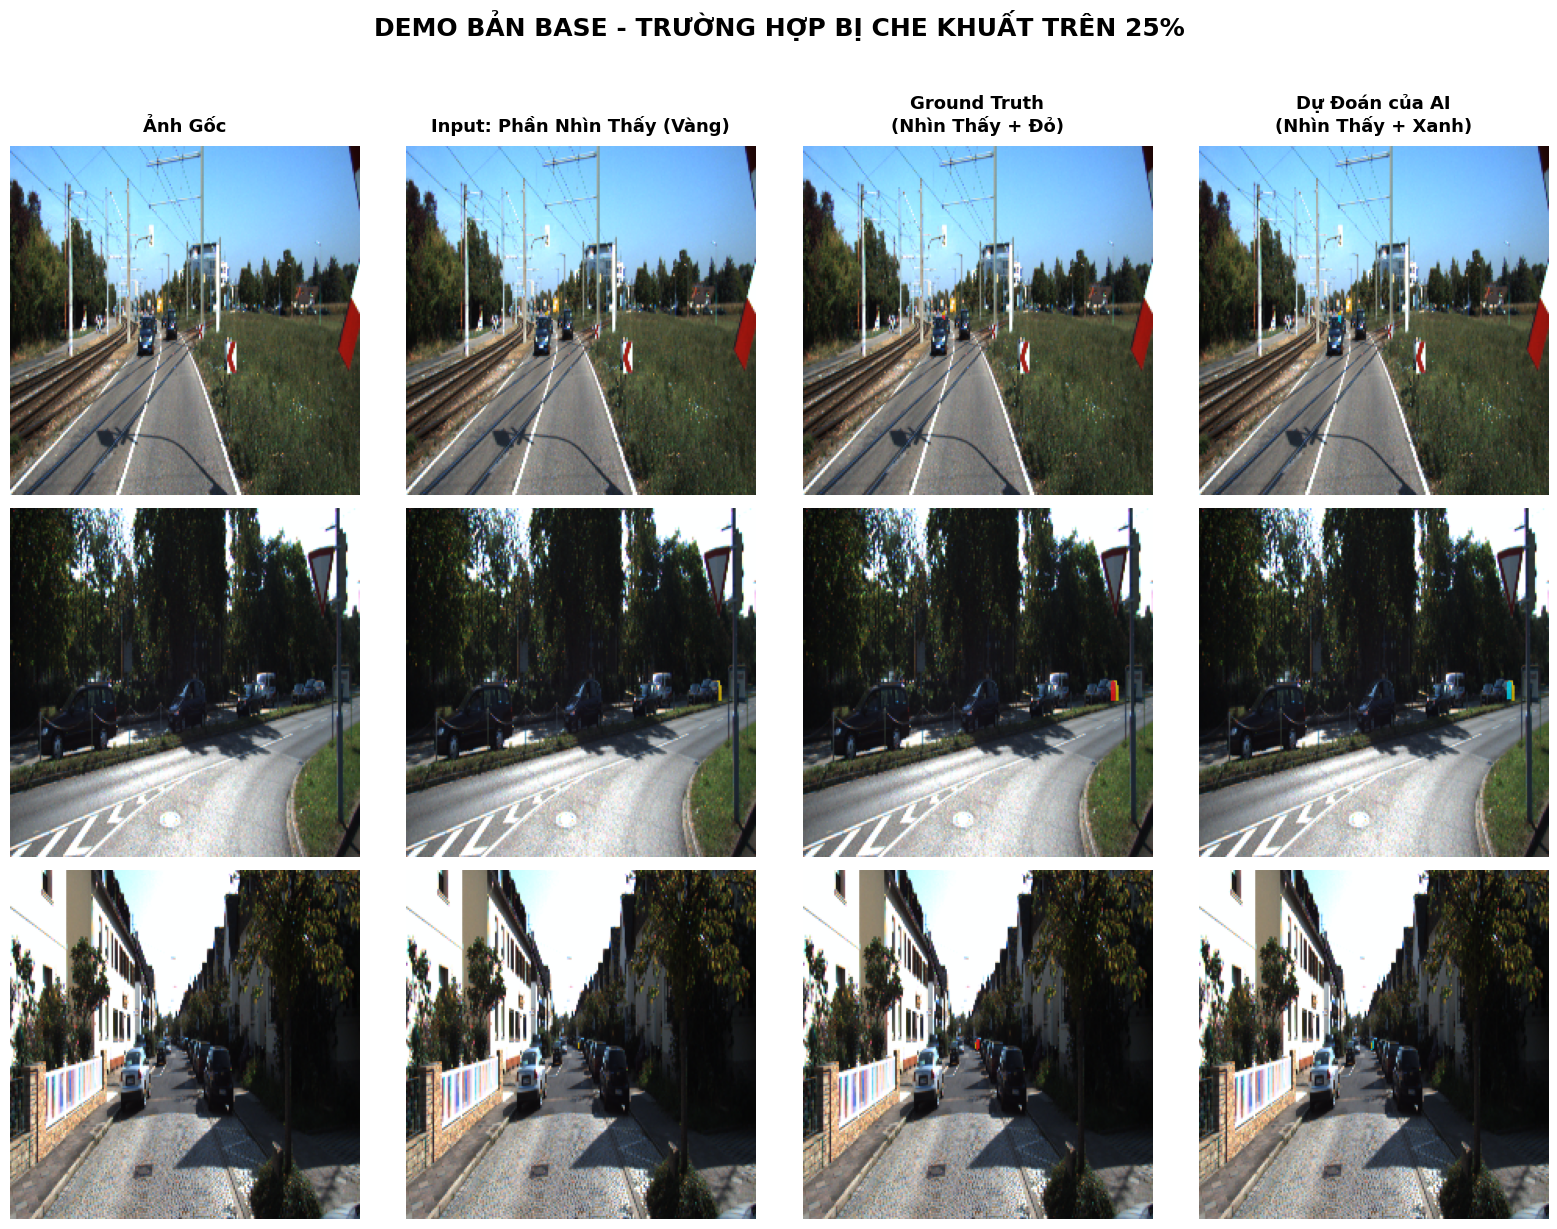

✅ Xong! Cậu xem AI vẽ có mượt không nhé.


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import albumentations as A
import sys

# Nhập các module tự viết
sys.path.append('/content/amodal_shape_prediction/src')
from dataset_kins import KINSDataset
from model import AmodalSwinUNet

def denormalize(tensor):
    """Biến đổi Tensor về ảnh màu RGB"""
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    img = tensor.cpu().numpy() * std + mean
    img = np.clip(img, 0, 1)
    return np.transpose(img, (1, 2, 0))

def get_color_mask(mask, color_rgb, alpha=0.6):
    """Tạo lớp phủ màu RGBA: Chỉ tô màu vùng mask > 0.5, còn lại trong suốt hoàn toàn"""
    h, w = mask.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    rgba[:, :, :3] = color_rgb # Đổ màu RGB
    rgba[:, :, 3] = (mask > 0.5).astype(np.float32) * alpha # Kênh Alpha điều khiển độ trong suốt
    return rgba

def show_demo_hard_cases():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🕵️‍♂️ Đang càn quét dữ liệu tìm ca 'chấn thương nặng' (>25% che khuất) trên {DEVICE}...")

    ann_file = "/content/kins_data/update_test_2020.json"
    img_dir = "/content/kitti_data/testing/image_2"
    transform = A.Compose([A.Resize(224, 224)], is_check_shapes=False)
    dataset = KINSDataset(img_dir=img_dir, ann_file=ann_file, transform=transform)

    # 1. Khởi tạo & Load BẢN BASE (Không Attention, file cũ của cậu)
    model_path = "/content/drive/MyDrive/CV+/checkpoints_kins/swin_amodal_KINS_epoch_30.pth"
    model = AmodalSwinUNet(num_classes=20, use_spatial_attention=False).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    # 2. Sàng lọc Data (>25% Occlusion)
    hard_samples = []
    indices = list(range(len(dataset)))
    random.shuffle(indices) # Xáo trộn để mỗi lần bấm chạy là ra 3 ảnh mới

    for idx in indices:
        inputs, targets, occluded, class_ids = dataset[idx]
        amodal_area = targets.sum().item()
        occluded_area = occluded.sum().item()

        # Nếu xe có tồn tại và diện tích che khuất > 25%
        if amodal_area > 0 and (occluded_area / amodal_area) > 0.4:
            hard_samples.append((inputs, targets, occluded, class_ids))

        if len(hard_samples) == 3: # Đủ 3 tấm thì dừng
            break

    if not hard_samples:
        print("Xui quá, không tìm thấy ảnh nào. Cậu chạy lại nhé!")
        return

    # Ghép thành batch để cho AI quét 1 lượt
    inputs_batch = torch.stack([s[0] for s in hard_samples]).to(DEVICE)
    class_ids_batch = torch.stack([s[3] for s in hard_samples]).to(DEVICE)
    targets_batch = torch.stack([s[1] for s in hard_samples])
    occluded_batch = torch.stack([s[2] for s in hard_samples])

    NUM_IMAGES = len(hard_samples)
    fig, axes = plt.subplots(NUM_IMAGES, 4, figsize=(16, 4 * NUM_IMAGES))
    if NUM_IMAGES == 1: axes = [axes] # Tránh lỗi nếu vô tình chỉ tìm được 1 ảnh

    plt.suptitle("DEMO BẢN BASE - TRƯỜNG HỢP BỊ CHE KHUẤT TRÊN 25%", fontsize=18, fontweight='bold', y=1.02)

    col_titles = ["Ảnh Gốc", "Input: Phần Nhìn Thấy (Vàng)", "Ground Truth\n(Nhìn Thấy + Đỏ)", "Dự Đoán của AI\n(Nhìn Thấy + Xanh)"]
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=13, pad=10, fontweight='bold')

    # Định nghĩa mã màu RGB chuẩn
    YELLOW = (1.0, 0.84, 0.0) # Vàng rực
    RED = (1.0, 0.1, 0.1)     # Đỏ báo động
    CYAN = (0.0, 0.9, 1.0)    # Xanh viễn tưởng

    print("🎨 Đang vẽ kết quả...")
    with torch.no_grad():
        outputs_batch = model(inputs_batch, class_ids_batch)
        pred_masks_batch = (torch.sigmoid(outputs_batch) > 0.5).float().cpu()

    for i in range(NUM_IMAGES):
        img_rgb = denormalize(inputs_batch[i, :3, :, :])
        visible_mask = inputs_batch[i, 3, :, :].cpu().numpy()
        gt_occluded = occluded_batch[i].squeeze().numpy()

        # Bóc tách phần che khuất dự đoán = Tổng dự đoán - Phần đã nhìn thấy
        pred_mask = pred_masks_batch[i].squeeze().numpy()
        pred_occluded = np.clip(pred_mask - visible_mask, 0, 1)

        # Cột 1: Gốc
        axes[i][0].imshow(img_rgb)
        axes[i][0].axis('off')

        # Cột 2: Input Nhìn Thấy (Vàng)
        axes[i][1].imshow(img_rgb)
        axes[i][1].imshow(get_color_mask(visible_mask, YELLOW, 0.7))
        axes[i][1].axis('off')

        # Cột 3: Ground Truth = Vàng (Nhìn thấy) + Đỏ (Bị che thật)
        axes[i][2].imshow(img_rgb)
        axes[i][2].imshow(get_color_mask(visible_mask, YELLOW, 0.7))
        axes[i][2].imshow(get_color_mask(gt_occluded, RED, 0.75))
        axes[i][2].axis('off')

        # Cột 4: Dự Đoán = Vàng (Nhìn thấy) + Xanh (Dự đoán bị che)
        axes[i][3].imshow(img_rgb)
        axes[i][3].imshow(get_color_mask(visible_mask, YELLOW, 0.7))
        axes[i][3].imshow(get_color_mask(pred_occluded, CYAN, 0.75))
        axes[i][3].axis('off')

    plt.tight_layout()
    plt.show()
    print("✅ Xong! Cậu xem AI vẽ có mượt không nhé.")

if __name__ == "__main__":
    show_demo_hard_cases()

🚀 Đang trích xuất Sample 69662 và làm nét chuẩn 4K...
loading annotations into memory...
Done (t=6.47s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 92625 vật thể!


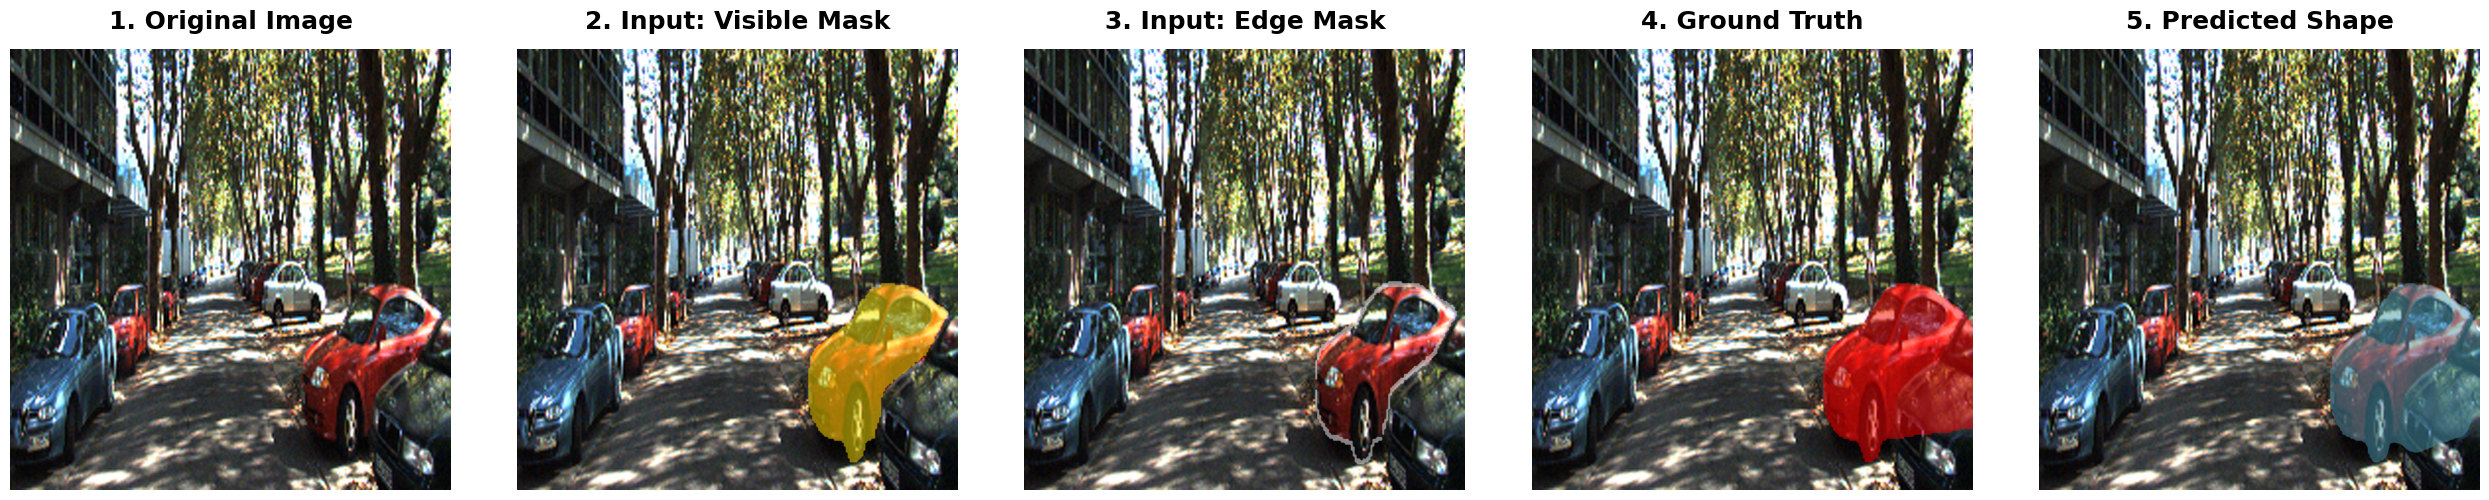

✅ Xong! Đã tạo khoảng trắng chuẩn bài báo. Sếp check xem ưng ý chưa nha!


In [ ]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import albumentations as A
from google.colab import drive

# --- KẾT NỐI & IMPORT ---
sys.path.append('/content/amodal_shape_prediction/src')
from dataset_kins import KINSDataset
from model import AmodalSwinUNet

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    img = tensor.cpu().numpy() * std + mean
    return np.clip(np.transpose(img, (1, 2, 0)), 0, 1)

def get_color_mask(mask, color_rgb, alpha=0.5):
    """Tạo lớp phủ màu cho mask với độ mượt cao"""
    h, w = mask.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    rgba[:, :, :3] = color_rgb
    rgba[:, :, 3] = mask * alpha # Dùng mask mềm để viền mịn hơn
    return rgba

def test_visualization_final():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. CẤU HÌNH ĐÍCH DANH
    TARGET_ID = 69662  # <--- GỌI ĐÚNG TÊN EM NÓ
    MODEL_PATH = "/content/drive/MyDrive/CV+/checkpoints_kins/swin_amodal_KINS_BASE_RESUME_epoch_46.pth"

    print(f"🚀 Đang trích xuất Sample {TARGET_ID} và làm nét chuẩn 4K...")

    # 2. KHỞI TẠO DATASET (Giữ nguyên transform 224 để inference)
    transform = A.Compose([A.Resize(224, 224)], is_check_shapes=False)
    dataset = KINSDataset(
        img_dir="/content/kitti_data/testing/image_2",
        ann_file="/content/kins_data/update_test_2020.json",
        transform=transform
    )

    # 3. LẤY DATA
    inputs, targets, occluded, class_ids = dataset[TARGET_ID]
    inputs_batch = inputs.unsqueeze(0).to(DEVICE)
    class_ids_batch = torch.tensor([class_ids]).to(DEVICE)

    # 4. LOAD MODEL (Cấu hình chuẩn 5 kênh + Embedding)
    model = AmodalSwinUNet(
        num_classes=20,
        use_spatial_attention=False,
        in_chans=5,                  # BẮT BUỘC 5 KÊNH
        use_category_embedding=True  # BẬT EMBEDDING
    ).to(DEVICE)

    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint)
    model.eval()

    # 5. INFERENCE
    with torch.no_grad():
        # Dùng chuẩn mới của PyTorch để hết bị Warning
        with torch.amp.autocast('cuda'):
            outputs = model(inputs_batch, class_ids_batch)
            # FIX LỖI Ở ĐÂY: Thêm .float() để ép về Float32 trước khi đưa cho OpenCV
            pred_mask = torch.sigmoid(outputs).squeeze().float().cpu().numpy()

    # 6. XỬ LÝ LÀM NÉT (UP-SAMPLING)
    # Tăng scale lên 4 lần nhưng dùng INTER_CUBIC để không bị vỡ hạt
    SCALE = 4
    HR_SIZE = (224 * SCALE, 224 * SCALE)

    img_hr = cv2.resize(denormalize(inputs[:3]), HR_SIZE, interpolation=cv2.INTER_CUBIC)

    # Ép kiểu an toàn cho các mask đầu vào
    vis_mask_numpy = inputs[3].float().numpy()
    edge_mask_numpy = inputs[4].float().numpy()
    gt_mask_numpy = targets.float().numpy()

    vis_mask_hr = cv2.resize(vis_mask_numpy, HR_SIZE, interpolation=cv2.INTER_CUBIC)
    edge_mask_hr = cv2.resize(edge_mask_numpy, HR_SIZE, interpolation=cv2.INTER_CUBIC)
    gt_mask_hr = cv2.resize(gt_mask_numpy, HR_SIZE, interpolation=cv2.INTER_CUBIC)
    pred_mask_hr = cv2.resize(pred_mask, HR_SIZE, interpolation=cv2.INTER_CUBIC)

    # 7. TÍNH TOÁN CẮT ẢNH (ZOOM XA HẲN RA ĐỂ HẾT MỜ)
    y_idx, x_idx = np.where(gt_mask_hr > 0.5)

    if len(y_idx) > 0 and len(x_idx) > 0:
        ymin, ymax, xmin, xmax = np.min(y_idx), np.max(y_idx), np.min(x_idx), np.max(x_idx)
    else:
        # Nếu mask rỗng (vật thể nhỏ quá), vẽ full ảnh
        ymin, ymax, xmin, xmax = 0, HR_SIZE[1], 0, HR_SIZE[0]

    # 🌟 ĐÃ TĂNG PAD TỪ 60 LÊN 150 ĐỂ KÉO CAMERA LÙI RA XA 🌟
    pad = 150 * SCALE
    ymin = max(0, ymin - pad)
    ymax = min(HR_SIZE[1], ymax + pad)
    xmin = max(0, xmin - pad)
    xmax = min(HR_SIZE[0], xmax + pad)

    # 8. VẼ HÌNH
    # 8. VẼ HÌNH
    # Chỉnh figsize dẹt lại một chút để ảnh không bị bự quá theo chiều dọc
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))

    colors = {
        'vis': (1.0, 0.9, 0.0),  # Vàng
        'edge': (1.0, 1.0, 1.0), # Trắng
        'gt': (1.0, 0.0, 0.0),   # Đỏ
        'pred': (0.3, 0.6, 0.7)  # Đổi màu xanh xám xám cho giống ảnh sếp gửi (Tùy chọn)
    }

    # Đổi title giống hệt format ảnh mẫu sếp gửi
    plot_data = [
        ("1. Original Image", img_hr, None, None),
        ("2. Input: Visible Mask", img_hr, vis_mask_hr, colors['vis']),
        ("3. Input: Edge Mask", img_hr, edge_mask_hr, colors['edge']),
        ("4. Ground Truth", img_hr, gt_mask_hr, colors['gt']),
        ("5. Predicted Shape", img_hr, pred_mask_hr, colors['pred'])
    ]

    for ax, (title, bg, mask, col) in zip(axes, plot_data):
        ax.imshow(bg, interpolation='lanczos')
        if mask is not None:
            binary_mask = (mask > 0.5).astype(np.float32)
            ax.imshow(get_color_mask(binary_mask, col), interpolation='bilinear')

        # pad=15 để đẩy cái dòng Title lên cao một chút, không bị dính vào viền ảnh
        ax.set_title(title, fontsize=18, fontweight='bold', pad=15)
        ax.axis('off')
        ax.set_xlim([xmin, xmax])
        ax.set_ylim([ymax, ymin])

    # 🌟 BÍ QUYẾT TẠO KHOẢNG TRẮNG GIỮA CÁC ẢNH NẰM Ở ĐÂY 🌟
    # w_pad=3.0 ép matplotlib tạo ra đệm giữa chiều ngang
    plt.tight_layout(w_pad=3.0)
    # Mở rộng wspace để các subplots đẩy nhau ra xa
    plt.subplots_adjust(wspace=0.15)

    # pad_inches=0.1 giúp ảnh lưu ra không bị dư viền trắng thừa thãi bên ngoài
    plt.savefig("sample_69662_HD_spaced.png", dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()
    print(f"✅ Xong! Đã tạo khoảng trắng chuẩn bài báo. Sếp check xem ưng ý chưa nha!")

if __name__ == "__main__":
    test_visualization_final()

🚀 Đang lùng sục ca chấn thương khó và Remaster làm nét ảnh...
loading annotations into memory...
Done (t=6.09s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 92625 vật thể!
🎯 BINGO! Đang xử lý làm nét Sample ID: 69662


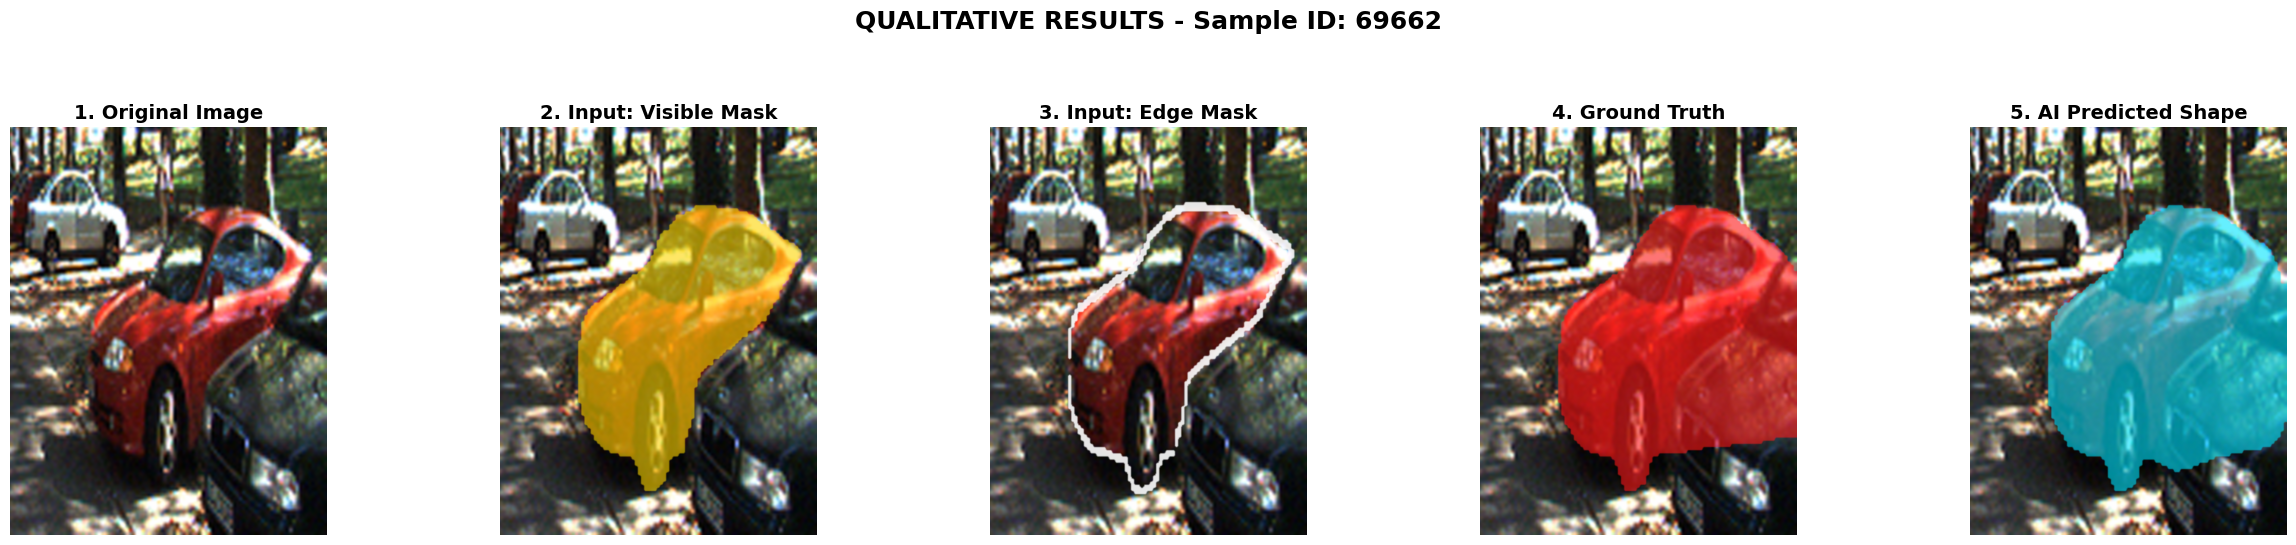

✅ Đã xuất ảnh siêu nét thành công! Tải file 'demo_remastered.png' về ném thẳng vào LaTeX nhé.


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import albumentations as A
import sys
import cv2  # Dùng cv2 để nội suy làm mịn ảnh

# Nhập các module tự viết từ thư mục source code
sys.path.append('/content/amodal_shape_prediction/src')
from dataset_kins import KINSDataset
from model import AmodalSwinUNet

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    img = tensor.cpu().numpy() * std + mean
    return np.clip(np.transpose(img, (1, 2, 0)), 0, 1)

def get_color_mask(mask, color_rgb, alpha=0.6):
    h, w = mask.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    rgba[:, :, :3] = color_rgb
    rgba[:, :, 3] = (mask > 0.5).astype(np.float32) * alpha
    return rgba

def smooth_upscale_mask(mask, size):
    """Phóng to và làm mượt đường cong của Mask (Chống răng cưa)"""
    m = cv2.resize(mask, size, interpolation=cv2.INTER_CUBIC)
    return (m > 0.5).astype(np.float32)

def test_pipeline_remastered():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Đang lùng sục ca chấn thương khó và Remaster làm nét ảnh...")

    ann_file = "/content/kins_data/update_test_2020.json"
    img_dir = "/content/kitti_data/testing/image_2"
    transform = A.Compose([A.Resize(224, 224)], is_check_shapes=False)
    dataset = KINSDataset(img_dir=img_dir, ann_file=ann_file, transform=transform)

    # Quét ảnh xe bự và bị che nhiều
    indices = list(range(len(dataset)))
    random.shuffle(indices)

    found_idx = -1
    for idx in indices:
        inputs, targets, occluded, class_ids = dataset[idx]
        amodal_area = targets.sum().item()
        occluded_area = occluded.sum().item()

        if amodal_area > 2000 and (occluded_area / amodal_area) > 0.25:
            found_idx = idx
            break

    if found_idx == -1:
        print("❌ Chưa tìm thấy, cậu chạy lại ô code này nhé!")
        return

    print(f"🎯 BINGO! Đang xử lý làm nét Sample ID: {found_idx}")
    inputs, targets, occluded, class_ids = dataset[found_idx]

    inputs_batch = inputs.unsqueeze(0).to(DEVICE)
    class_ids_batch = class_ids.unsqueeze(0).to(DEVICE)

    # Load Model (Bản Base)
    model_path = "/content/drive/MyDrive/CV+/checkpoints_kins/swin_amodal_KINS_epoch_30.pth"
    model = AmodalSwinUNet(num_classes=20, use_spatial_attention=False).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    with torch.no_grad():
        outputs = model(inputs_batch, class_ids_batch)
        pred_mask = (torch.sigmoid(outputs) > 0.5).float().cpu().squeeze().numpy()

    # Bóc tách 224x224
    img_rgb = denormalize(inputs[:3, :, :])
    visible_mask = inputs[3, :, :].numpy()
    edge_mask = inputs[4, :, :].numpy()
    gt_amodal = targets.numpy()

    # =========================================================
    # SUPER RESOLUTION: Phóng to x4 (Từ 224 lên 896) và Làm mượt
    # =========================================================
    SCALE = 4
    NEW_SIZE = (224 * SCALE, 224 * SCALE)

    img_rgb_hi = cv2.resize(img_rgb, NEW_SIZE, interpolation=cv2.INTER_CUBIC)
    visible_mask_hi = smooth_upscale_mask(visible_mask, NEW_SIZE)
    edge_mask_hi = smooth_upscale_mask(edge_mask, NEW_SIZE)
    gt_amodal_hi = smooth_upscale_mask(gt_amodal, NEW_SIZE)
    pred_mask_hi = smooth_upscale_mask(pred_mask, NEW_SIZE)

    # Tính Bounding Box trên ảnh Hi-Res
    y_idx, x_idx = np.where(gt_amodal_hi > 0)
    if len(y_idx) > 0:
        ymin, ymax = np.min(y_idx), np.max(y_idx)
        xmin, xmax = np.min(x_idx), np.max(x_idx)
        pad = 25 * SCALE # Căn lề an toàn cũng được phóng to
        ymin = max(0, ymin - pad)
        ymax = min(NEW_SIZE[1], ymax + pad)
        xmin = max(0, xmin - pad)
        xmax = min(NEW_SIZE[0], xmax + pad)
    else:
        ymin, ymax, xmin, xmax = 0, NEW_SIZE[1], 0, NEW_SIZE[0]

    # Màu sắc
    YELLOW = (1.0, 0.84, 0.0)
    WHITE = (1.0, 1.0, 1.0)
    RED = (1.0, 0.1, 0.1)
    CYAN = (0.0, 0.9, 1.0)

    # Vẽ hình (Dùng bicubic interpolation của matplotlib để hiển thị mịn hơn nữa)
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    plt.suptitle(f"QUALITATIVE RESULTS - Sample ID: {found_idx}", fontsize=18, fontweight='bold', y=1.08)

    plot_configs = [
        ("1. Original Image", img_rgb_hi, None, None),
        ("2. Input: Visible Mask", img_rgb_hi, visible_mask_hi, YELLOW),
        ("3. Input: Edge Mask", img_rgb_hi, edge_mask_hi, WHITE),
        ("4. Ground Truth", img_rgb_hi, gt_amodal_hi, RED),
        ("5. AI Predicted Shape", img_rgb_hi, pred_mask_hi, CYAN)
    ]

    for ax, (title, bg_img, mask, color) in zip(axes, plot_configs):
        ax.imshow(bg_img, interpolation='bicubic')
        if mask is not None:
            alpha = 0.9 if "Edge" in title else 0.6
            ax.imshow(get_color_mask(mask, color, alpha), interpolation='bicubic')

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')
        ax.set_xlim([xmin, xmax])
        ax.set_ylim([ymax, ymin])

    plt.tight_layout()
    plt.savefig("/content/demo_remastered.png", dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()
    print("✅ Đã xuất ảnh siêu nét thành công! Tải file 'demo_remastered.png' về ném thẳng vào LaTeX nhé.")

if __name__ == "__main__":
    test_pipeline_remastered()

**TRAIN THÊM 30 EPOCH CHO BẢN BASE (NO ATTENTION)**

In [ ]:
%%writefile /content/amodal_shape_prediction/src/train_kins.py
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import albumentations as A

from dataset_kins import KINSDataset
from model import AmodalSwinUNet

# 🔴 CẤU HÌNH TỔNG QUAN 🔴
USE_ATTENTION = False  # BẢN BASE (Không dùng Spatial Attention)
SAVE_NAME = "swin_amodal_KINS_BASE_RESUME" # Tên file lưu mới
RESUME_CHECKPOINT = "/content/drive/MyDrive/CV+/checkpoints_kins/swin_amodal_KINS_epoch_30.pth" # Đường dẫn model cũ

class OcclusionAwareLoss(nn.Module):
    def __init__(self, occlusion_weight=5.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(reduction="none")
        self.occlusion_weight = occlusion_weight

    def forward(self, pred, target, occluded_region):
        bce_loss = self.bce(pred, target)
        weight_matrix = torch.ones_like(target)
        weight_matrix[occluded_region > 0.5] = self.occlusion_weight
        weighted_bce = (bce_loss * weight_matrix).mean()
        pred_prob = torch.sigmoid(pred)
        intersection = (pred_prob * target).sum(dim=(2, 3))
        union = pred_prob.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice_loss = 1.0 - (2.0 * intersection + 1e-6) / (union + 1e-6)
        return weighted_bce + dice_loss.mean()

def train_resume():
    # 🔴 CẤU HÌNH CHO A100 🔴
    BATCH_SIZE = 128      # Bơm batch_size lên để tối ưu A100
    ADDITIONAL_EPOCHS = 30 # Số epoch muốn train thêm
    START_EPOCH = 30      # Bắt đầu tính log từ Epoch 30
    LR_RESUME = 2e-5      # Learning Rate nhỏ hơn để fine-tune
    NUM_WORKERS = 12      # Khai thác tối đa CPU của A100 instance

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 CHẾ ĐỘ: RESUME {SAVE_NAME} trên {DEVICE}")
    print(f"👉 Tiếp tục từ Epoch: {START_EPOCH}")

    train_transform = A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), rotate=(-15, 15), p=0.5),
        A.RandomBrightnessContrast(p=0.2),
    ])

    train_dataset = KINSDataset(img_dir="/content/kitti_data/training/image_2",
                               ann_file="/content/kins_data/update_train_2020.json",
                               transform=train_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)

    # 1. KHỞI TẠO MÔ HÌNH VÀ TẢI TRỌNG SỐ CŨ
    model = AmodalSwinUNet(num_classes=20, use_spatial_attention=USE_ATTENTION, in_chans=5).to(DEVICE)

    if os.path.exists(RESUME_CHECKPOINT):
        model.load_state_dict(torch.load(RESUME_CHECKPOINT, map_location=DEVICE))
        print(f"✅ Đã tải checkpoint: {RESUME_CHECKPOINT}")
    else:
        print(f"❌ KHÔNG TÌM THẤY CHECKPOINT! Vui lòng kiểm tra lại đường dẫn: {RESUME_CHECKPOINT}")
        return

    # 2. KHỞI TẠO OPTIMIZER & SCHEDULER
    criterion = OcclusionAwareLoss(occlusion_weight=5.0)
    optimizer = optim.AdamW(model.parameters(), lr=LR_RESUME)

    # Dùng CosineAnnealingLR để LR giảm dần mượt mà
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=ADDITIONAL_EPOCHS)
    scaler = torch.cuda.amp.GradScaler()

    # 3. BẮT ĐẦU VÒNG LẶP TRAIN TIẾP THEO
    for epoch in range(START_EPOCH, START_EPOCH + ADDITIONAL_EPOCHS):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{START_EPOCH + ADDITIONAL_EPOCHS}")

        for inputs, targets, occluded, class_ids in pbar:
            inputs = inputs.to(DEVICE, non_blocking=True)
            targets = targets.unsqueeze(1).float().to(DEVICE, non_blocking=True)
            occluded = occluded.unsqueeze(1).float().to(DEVICE, non_blocking=True)
            class_ids = class_ids.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(inputs, class_ids)
                loss = criterion(outputs, targets, occluded)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        scheduler.step() # Cập nhật Learning Rate sau mỗi epoch

        avg_loss = total_loss / len(train_loader)
        current_lr = scheduler.get_last_lr()[0]

        print(f"✅ Kết thúc Epoch {epoch+1} | Trung bình Loss: {avg_loss:.4f} | LR: {current_lr:.6f}")

        # Tạo thư mục lưu nếu chưa có
        os.makedirs("../checkpoints", exist_ok=True)
        torch.save(model.state_dict(), f"../checkpoints/{SAVE_NAME}_epoch_{epoch+1}.pth")

if __name__ == "__main__":
    train_resume()

Overwriting /content/amodal_shape_prediction/src/train_kins.py


In [ ]:
%cd /content/amodal_shape_prediction/src
!python train_kins.py

/content/amodal_shape_prediction/src
🚀 CHẾ ĐỘ: RESUME swin_amodal_KINS_BASE_RESUME trên cuda
👉 Tiếp tục từ Epoch: 30
loading annotations into memory...
Done (t=6.34s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 95460 vật thể!
model.safetensors: 100% 114M/114M [00:02<00:00, 56.4MB/s]
✅ Đã tải checkpoint: /content/drive/MyDrive/CV+/checkpoints_kins/swin_amodal_KINS_epoch_30.pth
/content/amodal_shape_prediction/src/train_kins.py:76: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 31/60:   0% 0/746 [00:00<?, ?it/s]/content/amodal_shape_prediction/src/train_kins.py:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 31/60: 100% 746/746 [05:04<00:00,  2.45it/s, loss=0.0598]
✅ Kết thúc Epoch 31 | Trung bình Loss: 0.0703 | LR: 0.000020
Epoch 

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import albumentations as A
import numpy as np
from tqdm import tqdm
import sys

# --- KẾT NỐI VÀ THÊM ĐƯỜNG DẪN ---
from google.colab import drive
drive.mount('/content/drive')
sys.path.append('/content/amodal_shape_prediction/src')

from dataset_kins import KINSDataset
from model import AmodalSwinUNet

# ==========================================
# CẤU HÌNH CÁC CHECKPOINT CẦN "SO GĂNG"
# ==========================================
# Đường dẫn lưu file tạ của đoạn code train ban nãy
BASE_DIR = "../checkpoints"
CHECKPOINTS = [ # Epoch có loss thấp nhất
    os.path.join(BASE_DIR, "swin_amodal_KINS_FULL_epoch_30.pth") # Epoch cuối cùng
]

def calculate_instance_metrics(pred, target, visible):
    """Tính điểm chuẩn SOTA cho từng chiếc xe một"""
    pred = (pred > 0.5).float()
    gt_occ = (target - visible) > 0.5
    pred_occ = (pred - visible) > 0.5

    batch_size = pred.shape[0]
    batch_overall_iou = []
    batch_occ_iou = []
    batch_occ_recall = []

    for i in range(batch_size):
        # 1. Overall mIoU
        inter_o = (pred[i] * target[i]).sum()
        union_o = pred[i].sum() + target[i].sum() - inter_o
        batch_overall_iou.append((inter_o / union_o).item() if union_o > 0 else 1.0)

        # 2. Occlusion (Chỉ tính vùng khuất)
        p_occ = pred_occ[i]
        t_occ = gt_occ[i]
        inter_occ = (p_occ * t_occ).sum()
        union_occ = p_occ.sum() + t_occ.sum() - inter_occ
        gt_occ_sum = t_occ.sum()

        if gt_occ_sum > 0: # Chỉ chấm nếu xe thực sự bị che
            batch_occ_iou.append((inter_occ / union_occ).item() if union_occ > 0 else 0.0)
            batch_occ_recall.append((inter_occ / gt_occ_sum).item())

    return batch_overall_iou, batch_occ_iou, batch_occ_recall

def evaluate_all():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 BẮT ĐẦU GIẢI ĐẤU TÌM NHÀ VÔ ĐỊCH TRÊN {DEVICE} 🚀\n")

    # 1. LOAD TẬP TEST/VAL CHUẨN MỰC (Không làm méo ảnh)
    transform_val = A.Compose([A.Resize(224, 224)], is_check_shapes=False)
    val_dataset = KINSDataset(img_dir="/content/kitti_data/testing/image_2",
                               ann_file="/content/kins_data/update_test_2020.json",
                               transform=transform_val)
    # Tận dụng tốc độ A100
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=8, pin_memory=True)

    # 2. KHỞI TẠO MODEL (5 Kênh, Không bật mắt thần)
    model = AmodalSwinUNet(num_classes=20, use_spatial_attention=True, in_chans=5).to(DEVICE)

    results = {}

    # 3. LẦN LƯỢT CHẤM ĐIỂM TỪNG CHECKPOINT
    for ckpt_path in CHECKPOINTS:
        epoch_name = os.path.basename(ckpt_path).split('_')[-1].replace('.pth', '')
        print(f"📦 Đang chấm điểm Epoch {epoch_name}...")

        if not os.path.exists(ckpt_path):
            print(f"   ❌ Không tìm thấy file {ckpt_path}. Bỏ qua!\n")
            continue

        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()

        all_overall = []
        all_occ_iou = []
        all_occ_recall = []

        with torch.no_grad():
            for inputs, targets, occluded, class_ids in tqdm(val_loader, desc=f"Scanning E{epoch_name}", leave=False):
                inputs = inputs.to(DEVICE, non_blocking=True)
                targets = targets.unsqueeze(1).to(DEVICE, non_blocking=True)
                visible_masks = inputs[:, 3:4, :, :]
                class_ids = class_ids.to(DEVICE, non_blocking=True)

                with torch.cuda.amp.autocast():
                    outputs = model(inputs, class_ids)

                pred_probs = torch.sigmoid(outputs)
                b_overall, b_occ, b_recall = calculate_instance_metrics(pred_probs, targets, visible_masks)

                all_overall.extend(b_overall)
                all_occ_iou.extend(b_occ)
                all_occ_recall.extend(b_recall)

        # Lưu lại điểm số
        results[epoch_name] = {
            "Overall": np.mean(all_overall) * 100,
            "Occ_mIoU": np.mean(all_occ_iou) * 100,
            "Occ_Recall": np.mean(all_occ_recall) * 100
        }
        print(f"   ✅ Xong Epoch {epoch_name}\n")

    # 4. IN BẢNG TỔNG SẮP (BẢNG VÀNG)
    print("="*65)
    print(f"{'🏆 BẢNG TỔNG SẮP KẾT QUẢ ĐÁNH GIÁ 3 CHECKPOINTS 🏆':^65}")
    print("="*65)
    print(f"| {'Epoch':^7} | {'Overall mIoU':^14} | {'Occlusion mIoU':^16} | {'Occ Recall':^12} |")
    print("-" * 65)

    best_occ_epoch = None
    best_occ_score = 0

    for epoch, metrics in results.items():
        print(f"| {epoch:^7} | {metrics['Overall']:>12.2f}% | {metrics['Occ_mIoU']:>14.2f}% | {metrics['Occ_Recall']:>10.2f}% |")
        if metrics['Occ_mIoU'] > best_occ_score:
            best_occ_score = metrics['Occ_mIoU']
            best_occ_epoch = epoch

    print("="*65)
    if best_occ_epoch:
        print(f"🌟 ĐỀ XUẤT CHO BÀI BÁO: Hãy lấy số liệu của Epoch {best_occ_epoch}!")
        print(f"🌟 (Vì nó có Occlusion mIoU cao nhất: {best_occ_score:.2f}%)")

if __name__ == "__main__":
    evaluate_all()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 BẮT ĐẦU GIẢI ĐẤU TÌM NHÀ VÔ ĐỊCH TRÊN cuda 🚀

loading annotations into memory...
Done (t=4.71s)
creating index...
index created!
🔥 Bóc tách KINS thành công: 92625 vật thể!


📦 Đang chấm điểm Epoch 30...


Scanning E30:   0%|          | 0/1448 [00:00<?, ?it/s]/tmp/ipykernel_556/3880872424.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


   ✅ Xong Epoch 30

        🏆 BẢNG TỔNG SẮP KẾT QUẢ ĐÁNH GIÁ 3 CHECKPOINTS 🏆         
|  Epoch  |  Overall mIoU  |  Occlusion mIoU  |  Occ Recall  |
-----------------------------------------------------------------
|   30    |        88.29% |          55.27% |      64.48% |
🌟 ĐỀ XUẤT CHO BÀI BÁO: Hãy lấy số liệu của Epoch 30!
🌟 (Vì nó có Occlusion mIoU cao nhất: 55.27%)
